Visualization routine for the 1D1D shock tube examples

In [8]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import scienceplots
plt.style.use(['science', 'nature', 'grid'])
import matplotlib.patheffects as patheffects
from matplotlib.lines import Line2D

import numpy as np
import pandas as pd

from LoadTSV import *

In [9]:
# Matplotlib settings
WIDTH = 6.0 
HEIGHT = 2.5

plt.rcParams.update({
    "figure.figsize": (WIDTH, HEIGHT),
    "font.size": 10,           # Matches thesis 10pt
    "axes.labelsize": 10,
    "legend.fontsize": 8,      # Slightly smaller for legends
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "lines.linewidth": 1,
    "lines.markersize": 4,
    "savefig.bbox": 'tight',   # Ensures no labels are cut off
    "savefig.pad_inches": 0.05
})

In [10]:
# Solver and simulation parameters
M_vector = [4, 5]
closure_vec = ["Gram", "ExtGram", "Grad"] # Grad for M=5 (Kn=1.0 and -> infty) diverged -> negative density
Knudsen = [0.1, 1.0, 10.0]
source_vec = ["relaxation_source", "relaxation_source", "zero_source"]
T_end = 0.3
base_tree_level = 10
polydeg = 1

# Initial condition parameters for the Riemann problem
rho_L = 7.0
v_L = 0.0
theta_L = 1.0
rho_R = 1.0
v_R = 0.0
theta_R = 1.0

x_lower = -2.0
x_upper = 2.0

# DVM
N = 1_000 
base_tree_level_DVM = 8
x_left_DVM = -5.0
x_right_DVM = 5.0
c_L = -6.0
c_R = 6.0

In [11]:
# Semi-analytical solution -> Collisionless
class Maxwellian:
    def __init__(self, rho, v, theta):
        self.rho = rho
        self.v = v
        self.theta = theta

    def __call__(self, c):
        return self.rho / np.sqrt(2*np.pi*self.theta) * np.exp(-(c-self.v)**2 / (2*self.theta))

def f0(f_left, f_right, x, c):
    x_arr, c_arr = np.broadcast_arrays(np.asarray(x), np.asarray(c))
    return np.where(x_arr < 0, f_left(c_arr), f_right(c_arr))
    
def f(f_left, f_right, x, c, t):
    return f0(f_left, f_right, x - c*t, c)

maxwellian_L = Maxwellian(rho_L, v_L, theta_L)
maxwellian_R = Maxwellian(rho_R, v_R, theta_R)

Nx = np.linspace(-6, 6, 10_000)
Nc = np.linspace(-10, 10, 10_000)
T = 0.3
f_T = f(maxwellian_L, maxwellian_R, Nx, Nc[:, None], T)
rho_T = np.trapz(f_T, Nc, axis=0)
v_T = np.trapz(Nc[:, None] * f_T, Nc, axis=0) / rho_T
theta_T = np.trapz((Nc[:, None] - v_T)**2 * f_T, Nc, axis=0) / rho_T
p_T = theta_T * rho_T

In [12]:
colors = ['blue', 'red', 'green', 'cyan', 'purple', 'black']
linestyles = ['--', '-', ':']

### Single Plots

In [13]:
# Plotting routine for density, velocity, and pressure profiles for different M, including DVM and semi-analytical solutions
def plotting(Moments, closure, Kn, source, figsize=(WIDTH, HEIGHT), show_legend=True):
    fig, axs = plt.subplots(figsize=figsize)
    twx = axs.twinx()
    for i, M in enumerate(Moments):
        file = f"../out/ShockTube/Moments/gram_solution_M{M}_closure{closure}_Kn{Kn}_source{source}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level}_polydeg{polydeg}_cons.tsv"

        x, u, _ = sol_final(file)
        rho = u[:, 0]
        v = u[:, 1] / rho
        p = (u[:, 2] - rho * v**2) # ?1/2 * u[:, 2]
        theta = p / rho

        axs.plot(x, rho, color=colors[i], ls=linestyles[0])
        twx.plot(x, v, color=colors[i], ls=linestyles[1])
        axs.plot(x, p, color=colors[i], ls=linestyles[2])
        axs.plot([], [], color=colors[i], ls='solid', label=f'$M={M}$')


        # DVM
        if source == "relaxation_source":
            data_DVM = pd.read_csv(f'../out/ShockTube/DVM/DVM_solution_N{N}_c_l{c_L}_c_u{c_R}_Kn{Kn}_source{source}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level_DVM}_polydeg{polydeg}_x_left{x_left_DVM}_x_right{x_right_DVM}_rho_v_p.csv')

            x_DVM = data_DVM['x'].to_numpy()

            rho_DVM = data_DVM['rho'].to_numpy()
            axs.plot(x_DVM, rho_DVM, color=colors[-1], ls=linestyles[0])

            v_DVM = data_DVM['v'].to_numpy()
            twx.plot(x_DVM, v_DVM, color=colors[-1], ls=linestyles[1])

            p_DVM = data_DVM['p'].to_numpy()
            theta_DVM = p_DVM / rho_DVM
            axs.plot(x_DVM, p_DVM, color=colors[-1], ls=linestyles[2])

            # --- Direct Labeling Logic ---
            effects = [patheffects.withStroke(linewidth=3, foreground="white")]
            
            # 1. Pressure: Left domain, below the curve
            idx_p = (np.abs(x_DVM - (-0.65))).argmin()
            axs.text(
                x_DVM[idx_p], p_DVM[idx_p] - 0.4, r'$p$', 
                fontsize=12, fontweight='bold', ha='center', va='top',
                path_effects=effects
            )

            # 2. Density: Left domain, slightly above the curve
            idx_rho = (np.abs(x_DVM - (-0.25))).argmin()
            axs.text(
                x_DVM[idx_rho], rho_DVM[idx_rho] + 0.7, r'$\rho$', 
                fontsize=12, fontweight='bold', ha='center', va='bottom',
                path_effects=effects
            )

            # 3. Velocity: Near the peak on the right side
            idx_v = (np.abs(x_DVM - (0.5))).argmin()
            twx.text(
                x_DVM[idx_v], np.max(v_DVM) * 9/10, r'$v$', 
                fontsize=12, fontweight='bold', ha='center', va='bottom',
                path_effects=effects
            )
        else: 
            axs.plot(Nx, rho_T, color=colors[-1], ls=linestyles[0])
            twx.plot(Nx, v_T, color=colors[-1], ls=linestyles[1])
            axs.plot(Nx, p_T, color=colors[-1], ls=linestyles[2])

            # --- Direct Labeling Logic ---
            effects = [patheffects.withStroke(linewidth=3, foreground="white")]
            
            # 1. Pressure: Left domain, below the curve
            idx_p = (np.abs(Nx - (-0.65))).argmin()
            axs.text(
                Nx[idx_p], p_T[idx_p] - 0.4, r'$p$', 
                fontsize=12, fontweight='bold', ha='center', va='top',
                path_effects=effects
            )

            # 2. Density: Left domain, slightly above the curve
            idx_rho = (np.abs(Nx - (-0.25))).argmin()
            axs.text(
                Nx[idx_rho], rho_T[idx_rho] + 0.7, r'$\rho$', 
                fontsize=12, fontweight='bold', ha='center', va='bottom',
                path_effects=effects
            )

            # 3. Velocity: Near the peak on the right side
            idx_v = (np.abs(Nx - (0.5))).argmin()
            twx.text(
                Nx[idx_v], np.max(v_T) * 9/10, r'$v$', 
                fontsize=12, fontweight='bold', ha='center', va='bottom',
                path_effects=effects
            )

    axs.set_ylabel('$\\rho$, $p$')
    twx.set_ylabel('$v$')
    axs.set_xlabel('$x$')
    axs.plot([], [], color=colors[-1], ls='solid', label='DVM')
    [axs.plot([], [], ls=linestyles[i], color='black', label=label_) for i, label_ in enumerate(['$\\rho$', '$v$', '$p$'])] 

    twx.grid(False) # only single grid
    [ax.set_xlim(-1.0, 1.0) for ax in [axs, twx]]
    if show_legend:
        axs.legend()
    fig.tight_layout()

    return fig, axs

/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_70966/2042315913.py:11: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_70966/2042315913.py:11: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_70966/2042315913.py:11: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_70966/2042315913.py:8: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_70966/2042315913.py:20: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_70966/2042315913.py:20: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be 

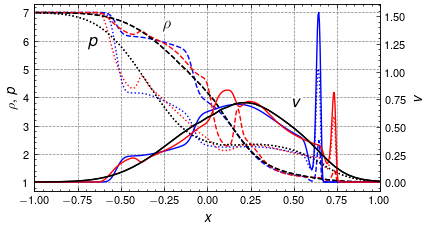

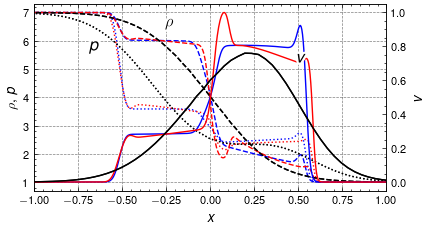

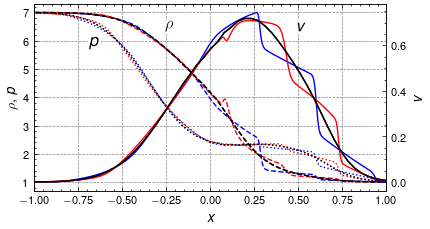

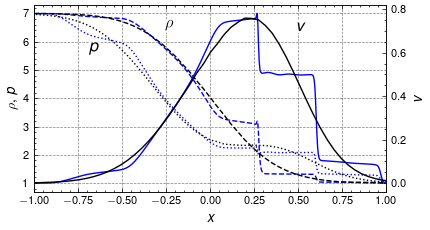

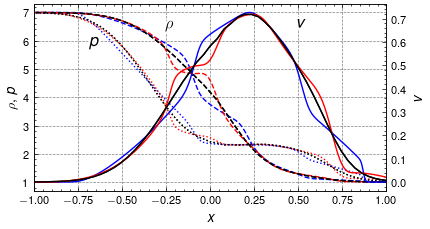

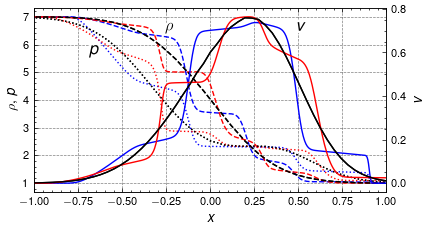

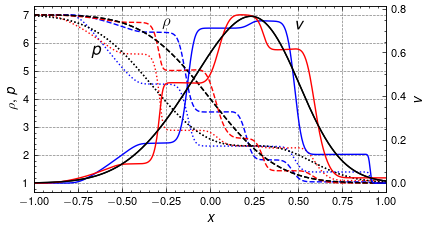

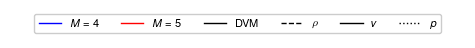

In [14]:
# Let's plot smth
Moments = [4, 5]
Knudsen_ = [0.1, 1.0]
for closure in ['Gram', 'Grad']:
    for Kn in Knudsen_:
        if closure == 'Grad' and Kn == 1.0:
            fig, axs = plotting([4], closure, Kn, 'relaxation_source', figsize=(.75*WIDTH, HEIGHT), show_legend=False)
            fig.show()
        else:
            fig, axs = plotting([4, 5], closure, Kn, 'relaxation_source', figsize=(.75*WIDTH, HEIGHT), show_legend=False)
            fig.show()
        fig.savefig(f'../out/Figures/ModelConvergence/ShockTube_M4_5_{closure}_Kn{Kn}.pdf')

Moments = [4, 5]
Knudsen_ = [0.1, 1.0, 10.0]#!, 10.0]
sources = ['relaxation_source', 'relaxation_source', 'zero_source'] #!'relaxation_source', 'zero_source']
closure = 'ExtGram'
for Kn, source in zip(Knudsen_, sources):
    fig, axs = plotting([4, 5], closure, Kn, source, figsize=(.75*WIDTH, HEIGHT), show_legend=False)
    fig.show()
    if source == 'relaxation_source':
        fig.savefig(f'../out/Figures/ModelConvergence/ShockTube_M4_5_{closure}_Kn{Kn}.pdf')
    else:
        fig.savefig(f'../out/Figures/ModelConvergence/ShockTube_M4_5_{closure}_zeroSource.pdf')

# Extract legend from one of the existing figures and save it as a separate PDF
fig_leg = plt.figure(figsize=(WIDTH, 0.5))
ax_leg = fig_leg.add_subplot(111)
ax_leg.axis('off')
# Grab handles from one existing axes
handles, labels = axs.get_legend_handles_labels()
ax_leg.legend(handles, labels, loc='center', ncol=6)
fig_leg.savefig('../out/Figures/ModelConvergence/legend_horizontal.pdf')

### ExtGram - Analysis

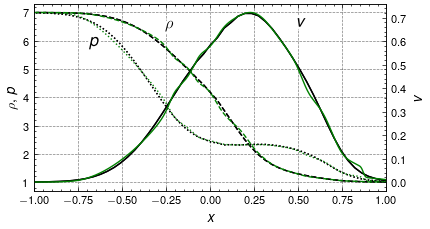

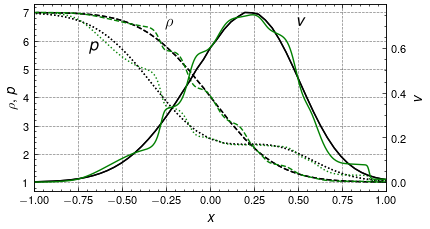

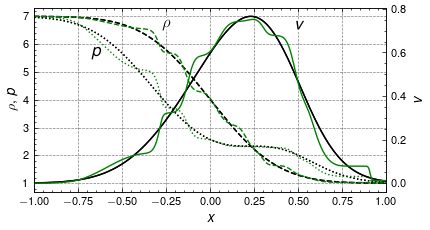

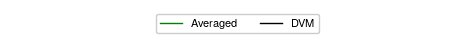

In [15]:
# Averaging M=4 and M=5 for ExtGram

Moments = [4, 5]
Knudsen_ = [0.1, 1.0, 10.0]
sources = ['relaxation_source', 'relaxation_source', 'zero_source']
closure = 'ExtGram'
figsize = (.75*WIDTH, HEIGHT)

for Kn, source in zip(Knudsen_, sources):
    fig, axs = plt.subplots(figsize=figsize)
    twx = axs.twinx()
    rho_vector, v_vector, p_vector = [], [], []
    for i, M in enumerate(Moments):
        file = f"../out/ShockTube/Moments/gram_solution_M{M}_closure{closure}_Kn{Kn}_source{source}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level}_polydeg{polydeg}_cons.tsv"

        x, u, _ = sol_final(file)
        rho = u[:, 0]
        v = u[:, 1] / rho
        p = (u[:, 2] - rho * v**2)
        theta = p / rho

        rho_vector.append(rho)
        v_vector.append(v)
        p_vector.append(p)

        # DVM
        if source == "relaxation_source":
            data_DVM = pd.read_csv(f'../out/ShockTube/DVM/DVM_solution_N{N}_c_l{c_L}_c_u{c_R}_Kn{Kn}_source{source}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level_DVM}_polydeg{polydeg}_x_left{x_left_DVM}_x_right{x_right_DVM}_rho_v_p.csv')

            x_DVM = data_DVM['x'].to_numpy()

            rho_DVM = data_DVM['rho'].to_numpy()
            axs.plot(x_DVM, rho_DVM, color=colors[-1], ls=linestyles[0])

            v_DVM = data_DVM['v'].to_numpy()
            twx.plot(x_DVM, v_DVM, color=colors[-1], ls=linestyles[1])

            p_DVM = data_DVM['p'].to_numpy()
            theta_DVM = p_DVM / rho_DVM
            axs.plot(x_DVM, p_DVM, color=colors[-1], ls=linestyles[2])

            # --- Direct Labeling Logic ---
            effects = [patheffects.withStroke(linewidth=3, foreground="white")]
            
            # 1. Pressure: Left domain, below the curve
            idx_p = (np.abs(x_DVM - (-0.65))).argmin()
            axs.text(
                x_DVM[idx_p], p_DVM[idx_p] - 0.4, r'$p$', 
                fontsize=12, fontweight='bold', ha='center', va='top',
                path_effects=effects
            )

            # 2. Density: Left domain, slightly above the curve
            idx_rho = (np.abs(x_DVM - (-0.25))).argmin()
            axs.text(
                x_DVM[idx_rho], rho_DVM[idx_rho] + 0.7, r'$\rho$', 
                fontsize=12, fontweight='bold', ha='center', va='bottom',
                path_effects=effects
            )

            # 3. Velocity: Near the peak on the right side
            idx_v = (np.abs(x_DVM - (0.5))).argmin()
            twx.text(
                x_DVM[idx_v], np.max(v_DVM) * 9/10, r'$v$', 
                fontsize=12, fontweight='bold', ha='center', va='bottom',
                path_effects=effects
            )
        else: 
            axs.plot(Nx, rho_T, color=colors[-1], ls=linestyles[0])
            twx.plot(Nx, v_T, color=colors[-1], ls=linestyles[1])
            axs.plot(Nx, p_T, color=colors[-1], ls=linestyles[2])

            # --- Direct Labeling Logic ---
            effects = [patheffects.withStroke(linewidth=3, foreground="white")]
            
            # 1. Pressure: Left domain, below the curve
            idx_p = (np.abs(Nx - (-0.65))).argmin()
            axs.text(
                Nx[idx_p], p_T[idx_p] - 0.4, r'$p$', 
                fontsize=12, fontweight='bold', ha='center', va='top',
                path_effects=effects
            )

            # 2. Density: Left domain, slightly above the curve
            idx_rho = (np.abs(Nx - (-0.25))).argmin()
            axs.text(
                Nx[idx_rho], rho_T[idx_rho] + 0.7, r'$\rho$', 
                fontsize=12, fontweight='bold', ha='center', va='bottom',
                path_effects=effects
            )

            # 3. Velocity: Near the peak on the right side
            idx_v = (np.abs(Nx - (0.5))).argmin()
            twx.text(
                Nx[idx_v], np.max(v_T) * 9/10, r'$v$', 
                fontsize=12, fontweight='bold', ha='center', va='bottom',
                path_effects=effects
            )

    rho_mean = np.mean(rho_vector, axis=0)
    v_mean = np.mean(v_vector, axis=0)
    p_mean = np.mean(p_vector, axis=0)
    axs.plot(x, rho_mean, color=colors[len(Moments)], ls=linestyles[0])
    twx.plot(x, v_mean, color=colors[len(Moments)], ls=linestyles[1])
    axs.plot(x, p_mean, color=colors[len(Moments)], ls=linestyles[2])

    axs.set_ylabel('$\\rho$, $p$')
    twx.set_ylabel('$v$')
    axs.set_xlabel('$x$')
    axs.plot([], [], color=colors[len(Moments)], ls='solid', label='Averaged')
    axs.plot([], [], color=colors[-1], ls='solid', label='DVM')

    twx.grid(False) # only single grid
    [ax.set_xlim(-1.0, 1.0) for ax in [axs, twx]]
    # axs.legend()
    fig.tight_layout()
    if source == 'relaxation_source':
        fig.savefig(f'../out/Figures/ModelConvergence/ShockTube_M4_5_{closure}_Kn{Kn}_avg.pdf')
    else:
        fig.savefig(f'../out/Figures/ModelConvergence/ShockTube_M4_5_{closure}_zerosource_avg.pdf')

# To save JUST the legend as a separate file
fig_leg = plt.figure(figsize=(WIDTH, 0.5))
ax_leg = fig_leg.add_subplot(111)
ax_leg.axis('off')
# Grab handles from one of your existing axes
handles, labels = axs.get_legend_handles_labels()
ax_leg.legend(handles, labels, loc='center', ncol=6)
fig_leg.savefig('../out/Figures/ModelConvergence/legend_horizontal_avg_method.pdf')

**Model Convergence**

/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_70966/1614754335.py:9: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_70966/1614754335.py:55: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-x" (-> linestyle='-'). The keyword argument will take precedence.
  axs_L1.semilogy(Moments_error, rho_L1, '-x', color=colors[3], ls=linestyles[0], label="$\\rho$")
/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_70966/1614754335.py:56: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-o" (-> linestyle='-'). The keyword argument will take precedence.
  axs_L1.semilogy(Moments_error, v_L1, '-o', color=colors[4], ls=linestyles[1], label='$v$')
/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_70966/1614754335.py:57: UserWarning: linestyle is redundantly defined by the

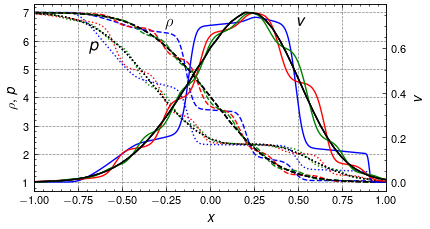

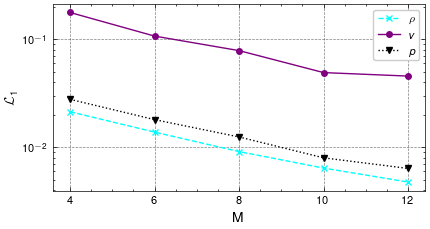

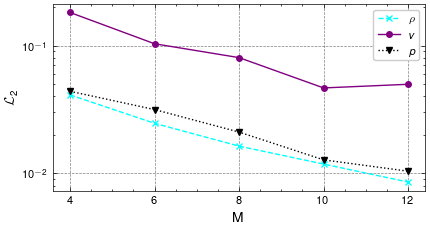

In [16]:
# Model Convergence

Moments = [4, 8, 12]
Moments_error = [4, 6, 8, 10, 12]
Kn = 1.0
source = 'relaxation_source'
closure = 'ExtGram'
fig, axs = plotting(Moments, closure, Kn, source, figsize=(.75*WIDTH, HEIGHT), show_legend=False)
fig.show()
if source == 'relaxation_source':
    fig.savefig(f'../out/Figures/ModelConvergence/ShockTube_M4_8_12_{closure}_Kn{Kn}.pdf')
else:
    fig.savefig(f'../out/Figures/ModelConvergence/ShockTube_M4_8_12_{closure}_zeroSource.pdf')

# DVM
data_DVM = pd.read_csv(f'../out/ShockTube/DVM/DVM_solution_N{N}_c_l{c_L}_c_u{c_R}_Kn{Kn}_source{source}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level_DVM}_polydeg{polydeg}_x_left{x_left_DVM}_x_right{x_right_DVM}_rho_v_p.csv')

x_DVM = data_DVM['x'].to_numpy()
rho_DVM = data_DVM['rho'].to_numpy()
v_DVM = data_DVM['v'].to_numpy()
p_DVM = data_DVM['p'].to_numpy()
theta_DVM = p_DVM / rho_DVM

rho_DVM_fct = lambda x_val: np.interp(x_val, x_DVM, rho_DVM)
v_DVM_fct = lambda x_val: np.interp(x_val, x_DVM, v_DVM)
p_DVM_fct = lambda x_val: np.interp(x_val, x_DVM, p_DVM)

rho_vector, v_vector, p_vector = [], [], []
rho_L1, v_L1, p_L1 = [], [], []
rho_L2, v_L2, p_L2 = [], [], []

for i, M in enumerate(Moments_error):
    # Moments
    file = f"../out/ShockTube/Moments/gram_solution_M{M}_closure{closure}_Kn{Kn}_source{source}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level}_polydeg{polydeg}_cons.tsv"

    x, u, _ = sol_final(file)
    rho = u[:, 0]
    rho_vector.append(rho)
    v = u[:, 1] / rho
    v_vector.append(v)
    p = (u[:, 2] - rho * v**2) # ?1/2 * u[:, 2]
    p_vector.append(p)
    theta = p / rho

    rho_L1.append(np.linalg.norm(rho_DVM_fct(x) - rho, 1) / np.linalg.norm(rho_DVM_fct(x), 1))
    rho_L2.append(np.linalg.norm(rho_DVM_fct(x) - rho, 2) / np.linalg.norm(rho_DVM_fct(x), 2))
    v_L1.append(np.linalg.norm(v_DVM_fct(x) - v, 1) / np.linalg.norm(v_DVM_fct(x), 1))
    v_L2.append(np.linalg.norm(v_DVM_fct(x) - v, 2) / np.linalg.norm(v_DVM_fct(x), 2))
    p_L1.append(np.linalg.norm(p_DVM_fct(x) - p, 1) / np.linalg.norm(p_DVM_fct(x), 1))
    p_L2.append(np.linalg.norm(p_DVM_fct(x) - p, 2) / np.linalg.norm(p_DVM_fct(x), 2))



fig_L1, axs_L1 = plt.subplots(figsize=(.75*WIDTH, HEIGHT))
axs_L1.semilogy(Moments_error, rho_L1, '-x', color=colors[3], ls=linestyles[0], label="$\\rho$")
axs_L1.semilogy(Moments_error, v_L1, '-o', color=colors[4], ls=linestyles[1], label='$v$')
axs_L1.semilogy(Moments_error, p_L1, '-v', color=colors[5], ls=linestyles[2], label='$p$')
axs_L1.legend()
axs_L1.set_xlabel('M')
axs_L1.set_ylabel('$\\mathcal{L}_1$')
axs_L1.set_xticks(Moments_error)

fig_L1.tight_layout()
fig_L1.savefig('../out/Figures/ModelConvergence/ShockTube_ModelConvergence_Even_L1.pdf')
fig_L1.show()



fig_L2, axs_L2 = plt.subplots(figsize=(.75*WIDTH, HEIGHT))
axs_L2.semilogy(Moments_error, rho_L2, '-x', color=colors[3], ls=linestyles[0], label="$\\rho$")
axs_L2.semilogy(Moments_error, v_L2, '-o', color=colors[4], ls=linestyles[1], label='$v$')
axs_L2.semilogy(Moments_error, p_L2, '-v', color=colors[5], ls=linestyles[2], label='$p$')
axs_L2.legend()
axs_L2.set_xlabel('M')
axs_L2.set_ylabel('$\\mathcal{L}_2$')
axs_L2.set_xticks(Moments_error)

fig_L2.tight_layout()
fig_L2.savefig('../out/Figures/ModelConvergence/ShockTube_ModelConvergence_Even_L2.pdf')
fig_L2.show()

/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_70966/2248313691.py:4: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_70966/2248313691.py:54: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-x" (-> linestyle='-'). The keyword argument will take precedence.
  axs_L1.semilogy(Moments_error, rho_L1, '-x', color=colors[3], ls=linestyles[0], label="$\\rho$")
/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_70966/2248313691.py:55: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-o" (-> linestyle='-'). The keyword argument will take precedence.
  axs_L1.semilogy(Moments_error, v_L1, '-o', color=colors[4], ls=linestyles[1], label='$v$')
/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_70966/2248313691.py:56: UserWarning: linestyle is redundantly defined by the

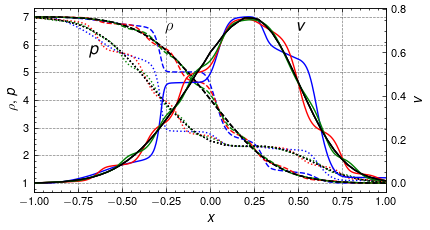

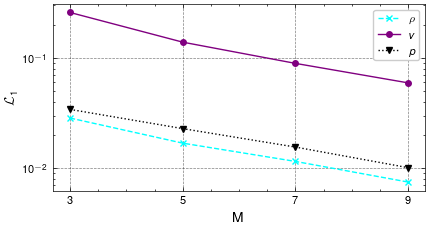

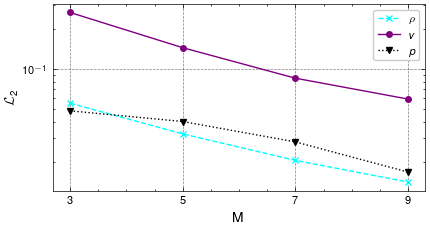

In [18]:
Moments = [5 ,9 , 13]
Moments_error = [3, 5, 7, 9]
fig, axs = plotting(Moments, closure, Kn, source, figsize=(.75*WIDTH, HEIGHT), show_legend=False)
fig.show()
if source == 'relaxation_source':
    fig.savefig(f'../out/Figures/ModelConvergence/ShockTube_M5_9_13_{closure}_Kn{Kn}.pdf')
else:
    fig.savefig(f'../out/Figures/ModelConvergence/ShockTube_M5_9_13_{closure}_zeroSource.pdf')



# Model Convergence

# DVM
data_DVM = pd.read_csv(f'../out/ShockTube/DVM/DVM_solution_N{N}_c_l{c_L}_c_u{c_R}_Kn{Kn}_source{source}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level_DVM}_polydeg{polydeg}_x_left{x_left_DVM}_x_right{x_right_DVM}_rho_v_p.csv')

x_DVM = data_DVM['x'].to_numpy()
rho_DVM = data_DVM['rho'].to_numpy()
v_DVM = data_DVM['v'].to_numpy()
p_DVM = data_DVM['p'].to_numpy()
theta_DVM = p_DVM / rho_DVM

rho_DVM_fct = lambda x_val: np.interp(x_val, x_DVM, rho_DVM)
v_DVM_fct = lambda x_val: np.interp(x_val, x_DVM, v_DVM)
p_DVM_fct = lambda x_val: np.interp(x_val, x_DVM, p_DVM)

rho_vector, v_vector, p_vector = [], [], []
rho_L1, v_L1, p_L1 = [], [], []
rho_L2, v_L2, p_L2 = [], [], []

for i, M in enumerate(Moments_error):
    # Moments
    file = f"../out/ShockTube/Moments/gram_solution_M{M}_closure{closure}_Kn{Kn}_source{source}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level}_polydeg{polydeg}_cons.tsv"

    x, u, _ = sol_final(file)
    rho = u[:, 0]
    rho_vector.append(rho)
    v = u[:, 1] / rho
    v_vector.append(v)
    p = (u[:, 2] - rho * v**2) # ?1/2 * u[:, 2]
    p_vector.append(p)
    theta = p / rho

    rho_L1.append(np.linalg.norm(rho_DVM_fct(x) - rho, 1) / np.linalg.norm(rho_DVM_fct(x), 1))
    rho_L2.append(np.linalg.norm(rho_DVM_fct(x) - rho, 2) / np.linalg.norm(rho_DVM_fct(x), 2))
    v_L1.append(np.linalg.norm(v_DVM_fct(x) - v, 1) / np.linalg.norm(v_DVM_fct(x), 1))
    v_L2.append(np.linalg.norm(v_DVM_fct(x) - v, 2) / np.linalg.norm(v_DVM_fct(x), 2))
    p_L1.append(np.linalg.norm(p_DVM_fct(x) - p, 1) / np.linalg.norm(p_DVM_fct(x), 1))
    p_L2.append(np.linalg.norm(p_DVM_fct(x) - p, 2) / np.linalg.norm(p_DVM_fct(x), 2))



fig_L1, axs_L1 = plt.subplots(figsize=(.75*WIDTH, HEIGHT))
axs_L1.semilogy(Moments_error, rho_L1, '-x', color=colors[3], ls=linestyles[0], label="$\\rho$")
axs_L1.semilogy(Moments_error, v_L1, '-o', color=colors[4], ls=linestyles[1], label='$v$')
axs_L1.semilogy(Moments_error, p_L1, '-v', color=colors[5], ls=linestyles[2], label='$p$')
axs_L1.legend()
axs_L1.set_xlabel('M')
axs_L1.set_ylabel('$\\mathcal{L}_1$')
axs_L1.set_xticks(Moments_error)

fig_L1.tight_layout()
fig_L1.savefig('../out/Figures/ModelConvergence/ShockTube_ModelConvergence_Odd_L1.pdf')
fig_L1.show()


fig_L2, axs_L2 = plt.subplots(figsize=(.75*WIDTH, HEIGHT))
axs_L2.semilogy(Moments_error, rho_L2, '-x', color=colors[3], ls=linestyles[0], label="$\\rho$")
axs_L2.semilogy(Moments_error, v_L2, '-o', color=colors[4], ls=linestyles[1], label='$v$')
axs_L2.semilogy(Moments_error, p_L2, '-v', color=colors[5], ls=linestyles[2], label='$p$')
axs_L2.legend()
axs_L2.set_xlabel('M')
axs_L2.set_ylabel('$\\mathcal{L}_2$')
axs_L2.set_xticks(Moments_error)

fig_L2.tight_layout()
fig_L2.savefig('../out/Figures/ModelConvergence/ShockTube_ModelConvergence_Odd_L2.pdf')
fig_L2.show()

<>:8: SyntaxWarning: invalid escape sequence '\{'
<>:9: SyntaxWarning: invalid escape sequence '\{'
<>:10: SyntaxWarning: invalid escape sequence '\{'
<>:8: SyntaxWarning: invalid escape sequence '\{'
<>:9: SyntaxWarning: invalid escape sequence '\{'
<>:10: SyntaxWarning: invalid escape sequence '\{'
/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_70966/2494260111.py:8: SyntaxWarning: invalid escape sequence '\{'
  Line2D([0], [0], color='blue', label='$M\\in\{4,5\}$'),
/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_70966/2494260111.py:9: SyntaxWarning: invalid escape sequence '\{'
  Line2D([0], [0], color='red', label='$M\\in\{8,9\}$'),
/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_70966/2494260111.py:10: SyntaxWarning: invalid escape sequence '\{'
  Line2D([0], [0], color='green', label='$M\\in\{12,13\}$'),


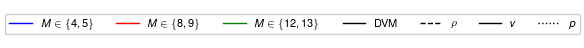

In [19]:
# And the legend

fig_leg = plt.figure(figsize=(WIDTH, 0.5))
ax_leg = fig_leg.add_subplot(111)
ax_leg.axis('off')

custom_handles = [
    Line2D([0], [0], color='blue', label='$M\\in\{4,5\}$'),
    Line2D([0], [0], color='red', label='$M\\in\{8,9\}$'),
    Line2D([0], [0], color='green', label='$M\\in\{12,13\}$'),
    Line2D([0], [0], color='black', label='DVM'),
    Line2D([0], [0], color='black', linestyle='dashed', label='$\\rho$'),
    Line2D([0], [0], color='black', linestyle='solid', label='$v$'),
    Line2D([0], [0], color='black', linestyle='dotted', label='$p$'),
]

ax_leg.legend(handles=custom_handles, loc='center', ncol=7)
fig_leg.savefig('../out/Figures/ModelConvergence/legend_horizontal_model_convergence.pdf')

### Larger Shock ($\rho_L=30.0$)

In [20]:
def plotting_large_shock(Moments, closure, Kn, source, figsize=(WIDTH, HEIGHT), show_legend=True):
    fig, axs = plt.subplots(figsize=figsize)
    twx = axs.twinx()
    for i, M in enumerate(Moments):
        file = f"../out/ShockTube/Moments/gram_solution_M{M}_closure{closure}_Kn{Kn}_source{source}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level}_polydeg{polydeg}_cons.tsv"

        x, u, _ = sol_final(file)
        rho = u[:, 0]
        v = u[:, 1] / rho
        p = (u[:, 2] - rho * v**2) # ?1/2 * u[:, 2]
        theta = p / rho

        axs.plot(x, rho, color=colors[i], ls=linestyles[0])
        twx.plot(x, v, color=colors[i], ls=linestyles[1])
        axs.plot(x, p, color=colors[i], ls=linestyles[2])
        axs.plot([], [], color=colors[i], ls='solid', label=f'$M={M}$')


        # DVM
        if source == "relaxation_source":
            data_DVM = pd.read_csv(f'../out/ShockTube/DVM/DVM_solution_N{N}_c_l{c_L}_c_u{c_R}_Kn{Kn}_source{source}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level_DVM}_polydeg{polydeg}_x_left{x_left_DVM}_x_right{x_right_DVM}_rho_v_p.csv')

            x_DVM = data_DVM['x'].to_numpy()

            rho_DVM = data_DVM['rho'].to_numpy()
            axs.plot(x_DVM, rho_DVM, color=colors[-1], ls=linestyles[0])

            v_DVM = data_DVM['v'].to_numpy()
            twx.plot(x_DVM, v_DVM, color=colors[-1], ls=linestyles[1])

            p_DVM = data_DVM['p'].to_numpy()
            theta_DVM = p_DVM / rho_DVM
            axs.plot(x_DVM, p_DVM, color=colors[-1], ls=linestyles[2])

            # --- Direct Labeling Logic ---
            effects = [patheffects.withStroke(linewidth=3, foreground="white")]
            
            # 1. Pressure: Left domain, below the curve
            idx_p = (np.abs(x_DVM - (-0.65))).argmin()
            axs.text(
                x_DVM[idx_p], p_DVM[idx_p] - 0.4*4, r'$p$', 
                fontsize=12, fontweight='bold', ha='center', va='top',
                path_effects=effects
            )

            # 2. Density: Left domain, slightly above the curve
            idx_rho = (np.abs(x_DVM - (-0.25))).argmin()
            axs.text(
                x_DVM[idx_rho], rho_DVM[idx_rho] + 0.7*4, r'$\rho$', 
                fontsize=12, fontweight='bold', ha='center', va='bottom',
                path_effects=effects
            )

            # 3. Velocity: Near the peak on the right side
            idx_v = (np.abs(x_DVM - (0.6))).argmin()
            twx.text(
                x_DVM[idx_v], np.max(v_DVM) * 9/10, r'$v$', 
                fontsize=12, fontweight='bold', ha='center', va='bottom',
                path_effects=effects
            )
        else: 
            axs.plot(Nx, rho_T, color=colors[-1], ls=linestyles[0])
            twx.plot(Nx, v_T, color=colors[-1], ls=linestyles[1])
            axs.plot(Nx, p_T, color=colors[-1], ls=linestyles[2])

            # --- Direct Labeling Logic ---
            effects = [patheffects.withStroke(linewidth=3, foreground="white")]
            
            # 1. Pressure: Left domain, below the curve
            idx_p = (np.abs(Nx - (-0.65))).argmin()
            axs.text(
                Nx[idx_p], p_T[idx_p] - 0.4*4, r'$p$', 
                fontsize=12, fontweight='bold', ha='center', va='top',
                path_effects=effects
            )

            # 2. Density: Left domain, slightly above the curve
            idx_rho = (np.abs(Nx - (-0.25))).argmin()
            axs.text(
                Nx[idx_rho], rho_T[idx_rho] + 0.7*4, r'$\rho$', 
                fontsize=12, fontweight='bold', ha='center', va='bottom',
                path_effects=effects
            )

            # 3. Velocity: Near the peak on the right side
            idx_v = (np.abs(Nx - (0.6))).argmin()
            twx.text(
                Nx[idx_v], np.max(v_T) * 9/10, r'$v$', 
                fontsize=12, fontweight='bold', ha='center', va='bottom',
                path_effects=effects
            )

    axs.set_ylabel('$\\rho$, $p$')
    twx.set_ylabel('$v$')
    axs.set_xlabel('$x$')
    axs.plot([], [], color=colors[-1], ls='solid', label='DVM')
    [axs.plot([], [], ls=linestyles[i], color='black', label=label_) for i, label_ in enumerate(['$\\rho$', '$v$', '$p$'])] 

    twx.grid(False) # only single grid
    [ax.set_xlim(-1.0, 1.0) for ax in [axs, twx]]
    if show_legend:
        axs.legend()
    fig.tight_layout()

    return fig, axs

/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_70966/3090760972.py:21: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_70966/3090760972.py:21: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


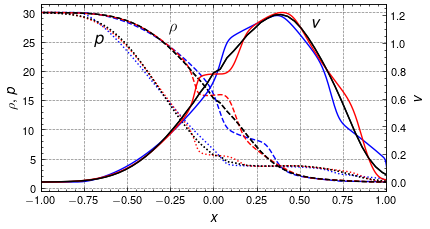

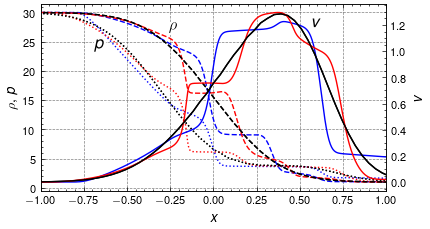

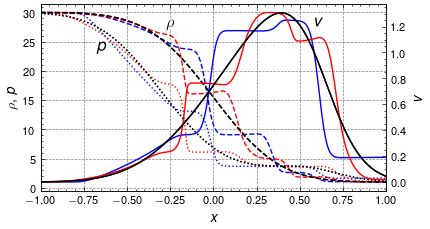

In [21]:
Moments = [4, 5]
Knudsen_ = [0.1, 1.0, 10.0]
sources = ['relaxation_source', 'relaxation_source', 'zero_source']
closure = 'ExtGram'

rho_L = 30.0
maxwellian_L = Maxwellian(rho_L, v_L, theta_L)
maxwellian_R = Maxwellian(rho_R, v_R, theta_R)

Nx = np.linspace(-6, 6, 10_000)
Nc = np.linspace(-10, 10, 10_000)
T = 0.3
f_T = f(maxwellian_L, maxwellian_R, Nx, Nc[:, None], T)
rho_T = np.trapz(f_T, Nc, axis=0)
v_T = np.trapz(Nc[:, None] * f_T, Nc, axis=0) / rho_T
theta_T = np.trapz((Nc[:, None] - v_T)**2 * f_T, Nc, axis=0) / rho_T
p_T = theta_T * rho_T

for Kn, source in zip(Knudsen_, sources):
    fig, axs = plotting_large_shock([4, 5], closure, Kn, source, figsize=(.75*WIDTH, HEIGHT), show_legend=False)
    fig.show()
    if source == 'relaxation_source':
        fig.savefig(f'../out/Figures/ModelConvergence/ShockTube_M4_5_rhoL{rho_L}_{closure}_Kn{Kn}.pdf')
    else:
        fig.savefig(f'../out/Figures/ModelConvergence/ShockTube_M4_5_rhoL{rho_L}_{closure}_zeroSource.pdf')

# Go Back to rho_L = 7.0 for next calculations
rho_L=7.0
maxwellian_L = Maxwellian(rho_L, v_L, theta_L)
maxwellian_R = Maxwellian(rho_R, v_R, theta_R)

Nx = np.linspace(-6, 6, 10_000)
Nc = np.linspace(-10, 10, 10_000)
T = 0.3
f_T = f(maxwellian_L, maxwellian_R, Nx, Nc[:, None], T)
rho_T = np.trapz(f_T, Nc, axis=0)
v_T = np.trapz(Nc[:, None] * f_T, Nc, axis=0) / rho_T
theta_T = np.trapz((Nc[:, None] - v_T)**2 * f_T, Nc, axis=0) / rho_T
p_T = theta_T * rho_T

### Some old plots

/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_70966/3807928186.py:81: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_70966/3807928186.py:81: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


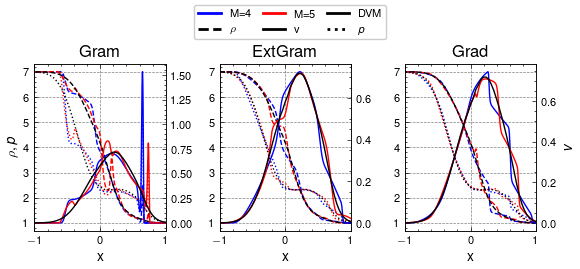

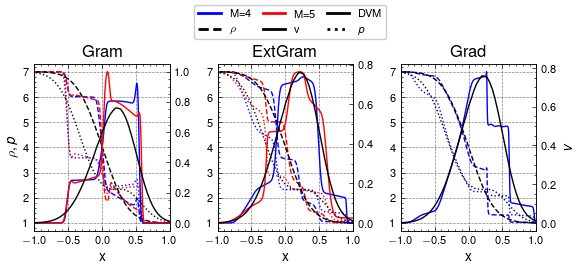

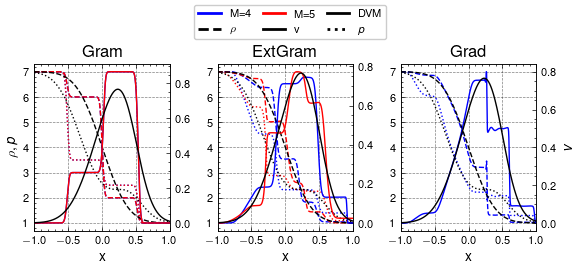

In [22]:
for i in range(len(Knudsen)):
    Kn = Knudsen[i]
    source = source_vec[i]
    fig, axs = plt.subplots(1, 3)
    twinx = [ax.twinx() for ax in axs]
    for j, closure in enumerate(closure_vec):
        # if source == "relaxation_source":
        #     fig.suptitle(f'Kn={Kn}')
        # else:
        #     fig.suptitle(f'Kn$\\to \\infty$')
        
        [ax.set_xlim(-1, 1) for ax in axs]
        [ax.set_xlabel('x') for ax in axs]
        axs[j].set_title(closure)
        for m, M in enumerate(M_vector):
            if closure == "Grad" and M==5 and Kn in [1.0, 10.0]:
                continue # diverged
            file = f"../out/ShockTube/Moments/gram_solution_M{M}_closure{closure}_Kn{Kn}_source{source}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level}_polydeg{polydeg}_cons.tsv"

            x, u, _ = sol_final(file)
            rho = u[:, 0]
            v = u[:, 1] / rho
            p = (u[:, 2] - rho * v**2) # ?1/2 * u[:, 2]
            theta = p / rho

            axs[j].plot(x, rho, color=colors[m], ls=linestyles[0])
            twinx[j].plot(x, v, color=colors[m], ls=linestyles[1])
            axs[j].plot(x, p, color=colors[m], ls=linestyles[2])


        # DVM
        if source == "relaxation_source":
            data_DVM = pd.read_csv(f'../out/ShockTube/DVM/DVM_solution_N{N}_c_l{c_L}_c_u{c_R}_Kn{Kn}_source{source}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level_DVM}_polydeg{polydeg}_x_left{x_left_DVM}_x_right{x_right_DVM}_rho_v_p.csv')

            x_DVM = data_DVM['x'].to_numpy()

            rho_DVM = data_DVM['rho'].to_numpy()
            axs[j].plot(x_DVM, rho_DVM, color=colors[-1], ls=linestyles[0])

            v_DVM = data_DVM['v'].to_numpy()
            twinx[j].plot(x_DVM, v_DVM, color=colors[-1], ls=linestyles[1])

            p_DVM = data_DVM['p'].to_numpy()
            theta_DVM = p_DVM / rho_DVM
            axs[j].plot(x_DVM, p_DVM, color=colors[-1], ls=linestyles[2])
        else: 
            axs[j].plot(Nx, rho_T, color=colors[-1], ls=linestyles[0])
            twinx[j].plot(Nx, v_T, color=colors[-1], ls=linestyles[1])
            axs[j].plot(Nx, p_T, color=colors[-1], ls=linestyles[2])

    elements = [
        Line2D([], [], color=colors[0], lw=2, label=f'M={M_vector[0]}'),
        Line2D([], [], color=colors[1], lw=2, label=f'M={M_vector[1]}'),
        Line2D([], [], color=colors[-1], lw=2, label='DVM')
    ] + [Line2D([], [], color='black', lw=2, ls=linestyles[i], label=label_) for i, label_ in enumerate(['$\\rho$', 'v', '$p$'])]
    elements = [ # sort moments in first row, variable in second
        elements[0], elements[3], elements[1],
        elements[4], elements[2], elements[5]
    ]

    leg = fig.legend(
        handles=elements, 
        loc='upper center', 
        bbox_to_anchor=(0.5, 1.12), 
        ncol=3, 
        # frameon=True,
        columnspacing=1.0 # Adjust spacing between columns
    )

    [twx.grid() for twx in twinx]
    axs[0].set_ylabel('$\\rho, p$')
    twinx[-1].set_ylabel('$v$')
    # [ax.set_ylabel('$\\rho, p$') for ax in axs]
    # [twx.set_ylabel('$v$') for twx in twinx]

    fig.tight_layout()
    if source == 'relaxation_source':
        fig.savefig(f'../out/Figures/ModelConvergence/ComareMethods_M4_5_Kn={Kn}.pdf')
    else:
        fig.savefig(f'../out/Figures/ModelConvergence/ComareMethods_M4_5_zerosource.pdf')
    fig.show()

In [23]:
colors = ['blue', 'orange', 'green', 'red', 'black', 'purple']

/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_70966/3138393135.py:51: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_70966/3138393135.py:60: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_70966/3138393135.py:51: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_70966/3138393135.py:60: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_70966/3138393135.py:51: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_70966/3138393135.py:60: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be

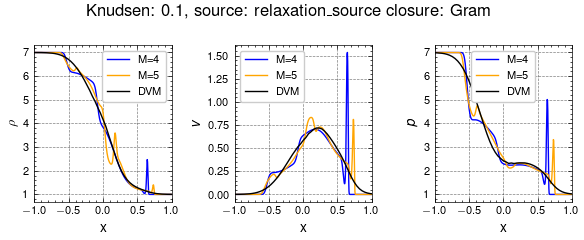

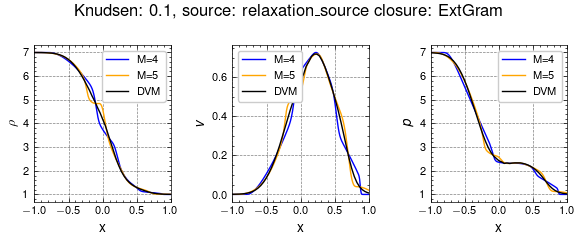

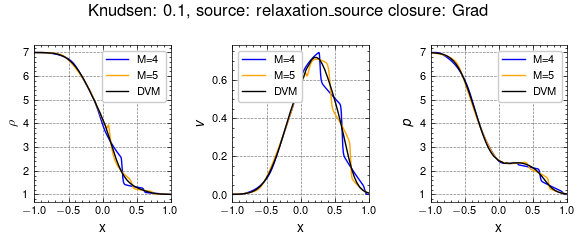

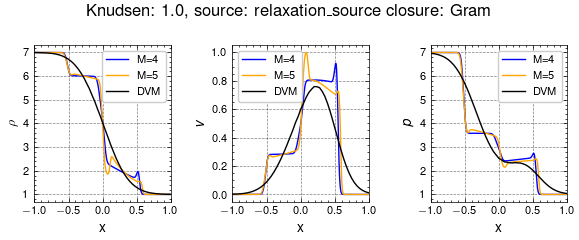

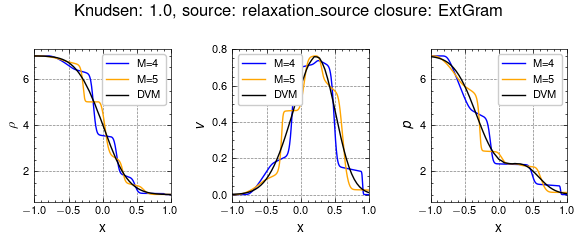

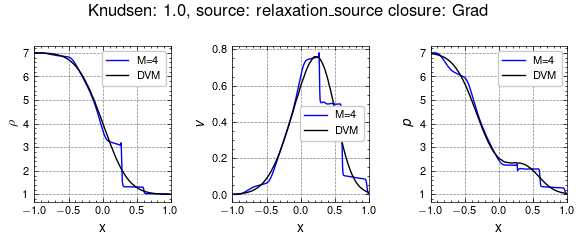

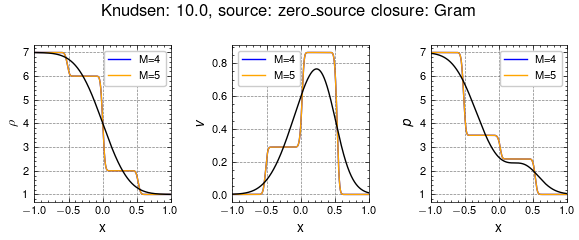

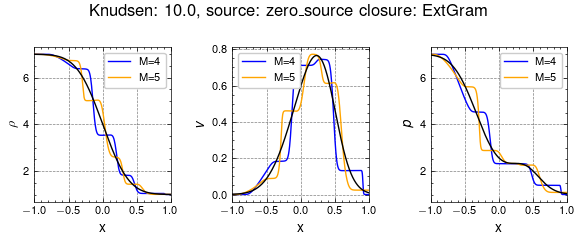

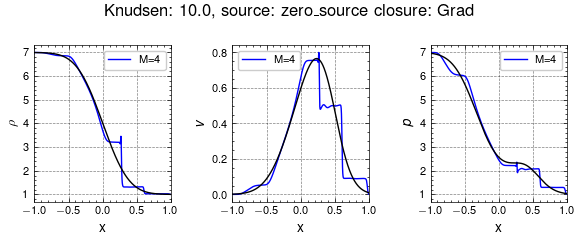

In [24]:
for i in range(len(Knudsen)):
    Kn = Knudsen[i]
    source = source_vec[i]
    for closure in closure_vec:
        fig, axs = plt.subplots(1, 3)
        fig.suptitle(f'Knudsen: {Kn}, source: {source} closure: {closure}')

        ax_rho = axs[0]
        ax_v = axs[1]
        ax_p = axs[2]
        
        [ax.set_xlim(-1, 1) for ax in [ax_rho, ax_v, ax_p]]
        [ax.set_xlabel('x') for ax in [ax_rho, ax_v, ax_p]]
        [ax.set_ylabel(label) for ax, label in zip([ax_rho, ax_v, ax_p], ['$\\rho$', '$v$', '$p$'])]
        for i, M in enumerate(M_vector):
            if closure == "Grad" and M==5 and Kn in [1.0, 10.0]:
                continue # diverged
            file = f"../out/ShockTube/Moments/gram_solution_M{M}_closure{closure}_Kn{Kn}_source{source}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level}_polydeg{polydeg}_cons.tsv"

            x, u, _ = sol_final(file)
            rho = u[:, 0]
            v = u[:, 1] / rho
            p = (u[:, 2] - rho * v**2) # ?1/2 * u[:, 2]
            theta = p / rho

            ax_rho.plot(x, rho, color=colors[i], label=f'M={M}')
            ax_v.plot(x, v, color=colors[i], label=f'M={M}')
            ax_p.plot(x, p, color=colors[i], label=f'M={M}')

        # DVM
        if source == "relaxation_source":
            data_DVM = pd.read_csv(f'../out/ShockTube/DVM/DVM_solution_N{N}_c_l{c_L}_c_u{c_R}_Kn{Kn}_source{source}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level_DVM}_polydeg{polydeg}_x_left{x_left_DVM}_x_right{x_right_DVM}_rho_v_p.csv')

            x_DVM = data_DVM['x'].to_numpy()

            rho_DVM = data_DVM['rho'].to_numpy()
            ax_rho.plot(x_DVM, rho_DVM, color=colors[4], label='DVM')

            v_DVM = data_DVM['v'].to_numpy()
            ax_v.plot(x_DVM, v_DVM, color=colors[4], label='DVM')

            p_DVM = data_DVM['p'].to_numpy()
            theta_DVM = p_DVM / rho_DVM
            ax_p.plot(x_DVM, p_DVM, color=colors[4], label='DVM')
        else: 
            ax_rho.plot(Nx, rho_T, color=colors[4])
            ax_v.plot(Nx, v_T, color=colors[4])
            ax_p.plot(Nx, p_T, color=colors[4])

        fig.tight_layout()
        fig.show()
        
        ax_rho.legend()
        ax_v.legend()
        ax_p.legend()
        # ax_eig_even.legend()
        # ax_eig_odd.legend()

        fig.tight_layout()
        fig.show()

/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_70966/4141062315.py:104: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_70966/4141062315.py:104: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


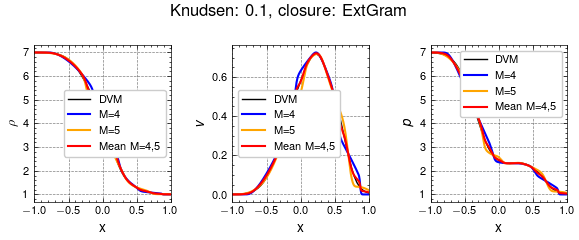

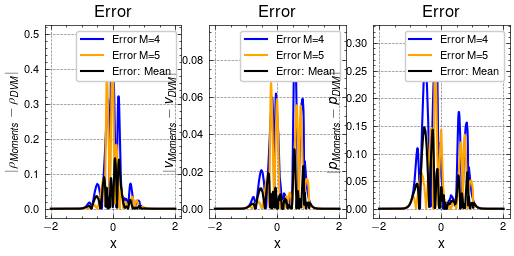

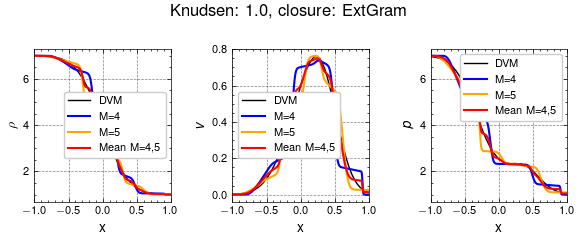

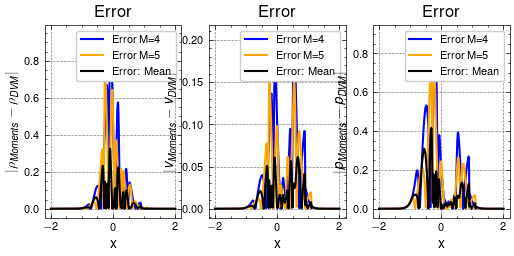

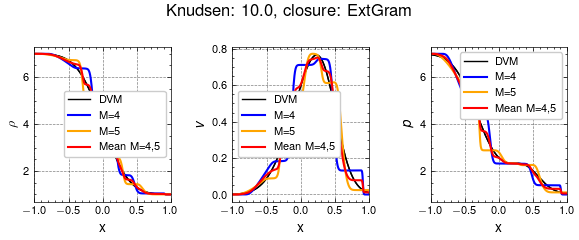

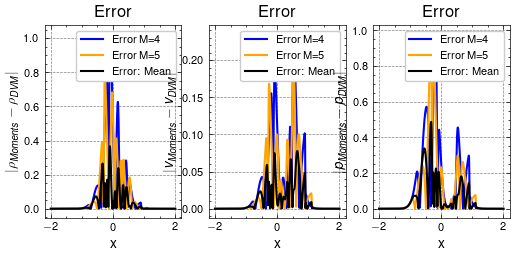

In [25]:
Moments = [4, 5]

for i in range(len(Knudsen)):
    Kn = Knudsen[i]
    source = source_vec[i]
    for closure in closure_vec:
        if closure != "ExtGram":
            continue # only interested in Extended Gramian here
        fig, axs = plt.subplots(1, 3)
        fig.suptitle(f'Knudsen: {Kn}, closure: {closure}')
        fig_error, axs_error = plt.subplots(1, 3)

        ax_rho = axs[0]
        ax_v = axs[1]
        ax_p = axs[2]
        
        [ax.set_xlim(-1, 1) for ax in [ax_rho, ax_v, ax_p]]
        [ax.set_xlabel('x') for ax in [ax_rho, ax_v, ax_p]]
        [ax.set_ylabel(label) for ax, label in zip([ax_rho, ax_v, ax_p], ['$\\rho$', '$v$', '$p$'])]

        # DVM
        if source == "relaxation_source":
            data_DVM = pd.read_csv(f'../out/ShockTube/DVM/DVM_solution_N{N}_c_l{c_L}_c_u{c_R}_Kn{Kn}_source{source}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level_DVM}_polydeg{polydeg}_x_left{x_left_DVM}_x_right{x_right_DVM}_rho_v_p.csv')

            x_DVM = data_DVM['x'].to_numpy()
            rho_DVM = data_DVM['rho'].to_numpy()
            v_DVM = data_DVM['v'].to_numpy()
            p_DVM = data_DVM['p'].to_numpy()
            theta_DVM = p_DVM / rho_DVM
        else: 
            x_DVM = Nx
            rho_DVM = rho_T
            v_DVM = v_T
            p_DVM = p_T
            ax_rho.plot(Nx, rho_T, color=colors[4])
            ax_v.plot(Nx, v_T, color=colors[4])
            ax_p.plot(Nx, p_T, color=colors[4])

        ax_rho.plot(x_DVM, rho_DVM, color=colors[4], label='DVM')
        ax_v.plot(x_DVM, v_DVM, color=colors[4], label='DVM')
        ax_p.plot(x_DVM, p_DVM, color=colors[4], label='DVM')

        rho_DVM_fct = lambda x_val: np.interp(x_val, x_DVM, rho_DVM)
        v_DVM_fct = lambda x_val: np.interp(x_val, x_DVM, v_DVM)
        p_DVM_fct = lambda x_val: np.interp(x_val, x_DVM, p_DVM)

        rho_vector, v_vector, p_vector = [], [], []
        
        for i, M in enumerate(Moments):
            if closure == "Grad" and M==5:
                continue # diverged
            # Moments
            file = f"../out/ShockTube/Moments/gram_solution_M{M}_closure{closure}_Kn{Kn}_source{source}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level}_polydeg{polydeg}_cons.tsv"

            x, u, _ = sol_final(file)
            rho = u[:, 0]
            rho_vector.append(rho)
            v = u[:, 1] / rho
            v_vector.append(v)
            p = (u[:, 2] - rho * v**2) # ?1/2 * u[:, 2]
            p_vector.append(p)
            theta = p / rho

            ax_rho.plot(x, rho, color=colors[i], lw=1.5, label=f'M={M}')
            ax_v.plot(x, v, color=colors[i], lw=1.5, label=f'M={M}')
            ax_p.plot(x, p, color=colors[i], lw=1.5, label=f'M={M}')

            axs_error[0].plot(x, np.abs(rho_DVM_fct(x) - rho), color=colors[i], lw=1.5, label=f'Error M={M}')
            axs_error[1].plot(x, np.abs(v_DVM_fct(x) - v), color=colors[i], lw=1.5, label=f'Error M={M}')
            axs_error[2].plot(x, np.abs(p_DVM_fct(x) - p), color=colors[i], lw=1.5, label=f'Error M={M}')

        # Mean of M=4 and M=5
        if closure != "Grad":
            rho_mean = 0.5 * (rho_vector[0] + rho_vector[1])
            v_mean = 0.5 * (v_vector[0] + v_vector[1])
            p_mean = 0.5 * (p_vector[0] + p_vector[1])

            ax_rho.plot(x, rho_mean, color=colors[3], lw=1.5, label=f'Mean M={Moments[0]},{Moments[1]}')
            ax_v.plot(x, v_mean, color=colors[3], lw=1.5, label=f'Mean M={Moments[0]},{Moments[1]}')
            ax_p.plot(x, p_mean, color=colors[3], lw=1.5, label=f'Mean M={Moments[0]},{Moments[1]}')
        
        ax_rho.legend()
        ax_v.legend()
        ax_p.legend()

        if closure != "Grad":
            axs_error[0].set_title('Error')
            axs_error[0].set_xlabel('x')
            axs_error[0].set_ylabel('$|\\rho_{Moments} - \\rho_{DVM}|$')
            axs_error[1].set_title('Error')
            axs_error[1].set_xlabel('x')
            axs_error[1].set_ylabel('$|v_{Moments} - v_{DVM}|$')
            axs_error[2].set_title('Error')
            axs_error[2].set_xlabel('x')
            axs_error[2].set_ylabel('$|p_{Moments} - p_{DVM}|$')

            axs_error[0].plot(x, np.abs(rho_DVM_fct(x) - rho_mean), color='black', lw=1.5, label="Error: Mean")
            axs_error[1].plot(x, np.abs(v_DVM_fct(x) - v_mean), color='black', lw=1.5, label="Error: Mean")
            axs_error[2].plot(x, np.abs(p_DVM_fct(x) - p_mean), color='black', lw=1.5, label="Error: Mean")

        [ax.legend() for ax in axs_error]

        fig.tight_layout()
        fig.show()

/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_70966/26076916.py:104: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_70966/26076916.py:104: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_70966/26076916.py:104: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


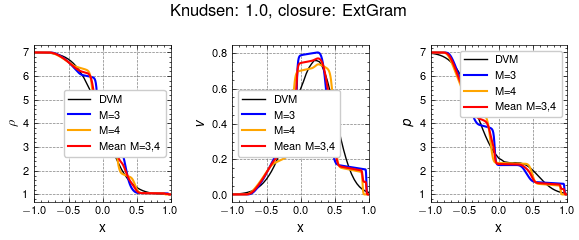

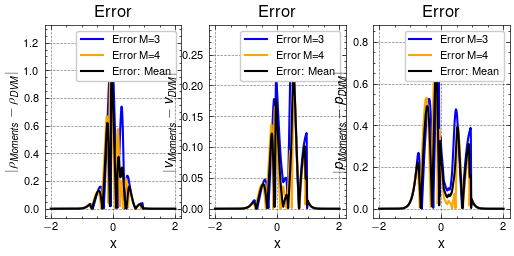

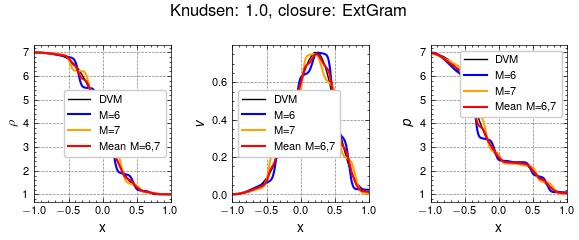

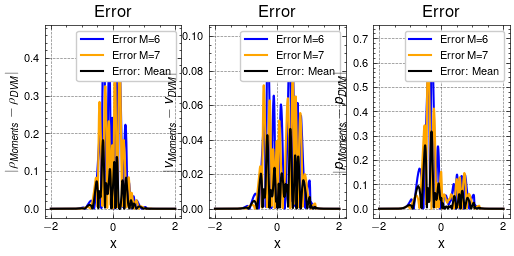

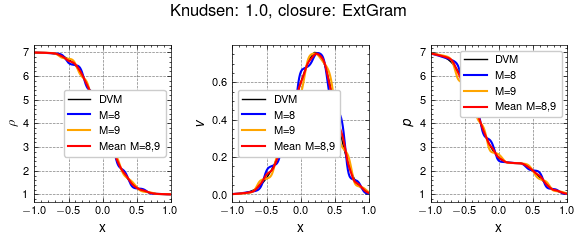

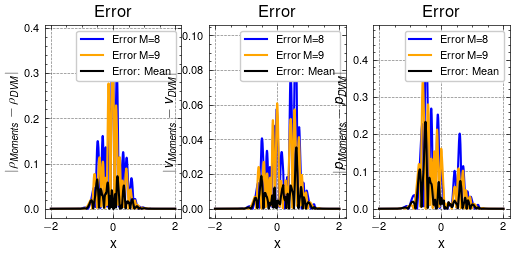

In [26]:
Moments_collected = [[3, 4], [6, 7], [8,9]]
Kn = 1.0
source = "relaxation_source"

for Moments in Moments_collected:
    for closure in closure_vec:
        if closure != "ExtGram":
            continue # only interested in Extended Gramian here
        fig, axs = plt.subplots(1, 3)
        fig.suptitle(f'Knudsen: {Kn}, closure: {closure}')
        fig_error, axs_error = plt.subplots(1, 3)

        ax_rho = axs[0]
        ax_v = axs[1]
        ax_p = axs[2]
        
        [ax.set_xlim(-1, 1) for ax in [ax_rho, ax_v, ax_p]]
        [ax.set_xlabel('x') for ax in [ax_rho, ax_v, ax_p]]
        [ax.set_ylabel(label) for ax, label in zip([ax_rho, ax_v, ax_p], ['$\\rho$', '$v$', '$p$'])]

        # DVM
        if source == "relaxation_source":
            data_DVM = pd.read_csv(f'../out/ShockTube/DVM/DVM_solution_N{N}_c_l{c_L}_c_u{c_R}_Kn{Kn}_source{source}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level_DVM}_polydeg{polydeg}_x_left{x_left_DVM}_x_right{x_right_DVM}_rho_v_p.csv')

            x_DVM = data_DVM['x'].to_numpy()
            rho_DVM = data_DVM['rho'].to_numpy()
            v_DVM = data_DVM['v'].to_numpy()
            p_DVM = data_DVM['p'].to_numpy()
            theta_DVM = p_DVM / rho_DVM
        else: 
            x_DVM = Nx
            rho_DVM = rho_T
            v_DVM = v_T
            p_DVM = p_T
            ax_rho.plot(Nx, rho_T, color=colors[4])
            ax_v.plot(Nx, v_T, color=colors[4])
            ax_p.plot(Nx, p_T, color=colors[4])

        ax_rho.plot(x_DVM, rho_DVM, color=colors[4], label='DVM')
        ax_v.plot(x_DVM, v_DVM, color=colors[4], label='DVM')
        ax_p.plot(x_DVM, p_DVM, color=colors[4], label='DVM')

        rho_DVM_fct = lambda x_val: np.interp(x_val, x_DVM, rho_DVM)
        v_DVM_fct = lambda x_val: np.interp(x_val, x_DVM, v_DVM)
        p_DVM_fct = lambda x_val: np.interp(x_val, x_DVM, p_DVM)

        rho_vector, v_vector, p_vector = [], [], []
        
        for i, M in enumerate(Moments):
            if closure == "Grad" and M==5:
                continue # diverged
            # Moments
            file = f"../out/ShockTube/Moments/gram_solution_M{M}_closure{closure}_Kn{Kn}_source{source}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level}_polydeg{polydeg}_cons.tsv"

            x, u, _ = sol_final(file)
            rho = u[:, 0]
            rho_vector.append(rho)
            v = u[:, 1] / rho
            v_vector.append(v)
            p = (u[:, 2] - rho * v**2) # ?1/2 * u[:, 2]
            p_vector.append(p)
            theta = p / rho

            ax_rho.plot(x, rho, color=colors[i], lw=1.5, label=f'M={M}')
            ax_v.plot(x, v, color=colors[i], lw=1.5, label=f'M={M}')
            ax_p.plot(x, p, color=colors[i], lw=1.5, label=f'M={M}')

            axs_error[0].plot(x, np.abs(rho_DVM_fct(x) - rho), color=colors[i], lw=1.5, label=f'Error M={M}')
            axs_error[1].plot(x, np.abs(v_DVM_fct(x) - v), color=colors[i], lw=1.5, label=f'Error M={M}')
            axs_error[2].plot(x, np.abs(p_DVM_fct(x) - p), color=colors[i], lw=1.5, label=f'Error M={M}')

        # Mean of M=4 and M=5
        if closure != "Grad":
            rho_mean = 0.5 * (rho_vector[0] + rho_vector[1])
            v_mean = 0.5 * (v_vector[0] + v_vector[1])
            p_mean = 0.5 * (p_vector[0] + p_vector[1])

            ax_rho.plot(x, rho_mean, color=colors[3], lw=1.5, label=f'Mean M={Moments[0]},{Moments[1]}')
            ax_v.plot(x, v_mean, color=colors[3], lw=1.5, label=f'Mean M={Moments[0]},{Moments[1]}')
            ax_p.plot(x, p_mean, color=colors[3], lw=1.5, label=f'Mean M={Moments[0]},{Moments[1]}')
        
        ax_rho.legend()
        ax_v.legend()
        ax_p.legend()

        if closure != "Grad":
            axs_error[0].set_title('Error')
            axs_error[0].set_xlabel('x')
            axs_error[0].set_ylabel('$|\\rho_{Moments} - \\rho_{DVM}|$')
            axs_error[1].set_title('Error')
            axs_error[1].set_xlabel('x')
            axs_error[1].set_ylabel('$|v_{Moments} - v_{DVM}|$')
            axs_error[2].set_title('Error')
            axs_error[2].set_xlabel('x')
            axs_error[2].set_ylabel('$|p_{Moments} - p_{DVM}|$')

            axs_error[0].plot(x, np.abs(rho_DVM_fct(x) - rho_mean), color='black', lw=1.5, label="Error: Mean")
            axs_error[1].plot(x, np.abs(v_DVM_fct(x) - v_mean), color='black', lw=1.5, label="Error: Mean")
            axs_error[2].plot(x, np.abs(p_DVM_fct(x) - p_mean), color='black', lw=1.5, label="Error: Mean")

        [ax.legend() for ax in axs_error]

        fig.tight_layout()
        fig.show()

## Convergence for ExtGram

/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_70966/1350688212.py:102: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_70966/1350688212.py:112: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig_L1.show()
/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_70966/1350688212.py:127: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig_L2.show()
/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_70966/1350688212.py:102: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_70966/1350688212.py:112: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig_L1.show()
/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_70966/1350688212.py:127: UserWarning: FigureCanvasAgg is non-interactive, and

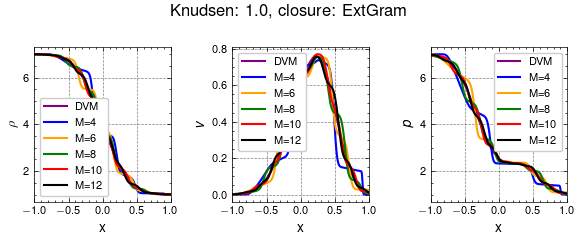

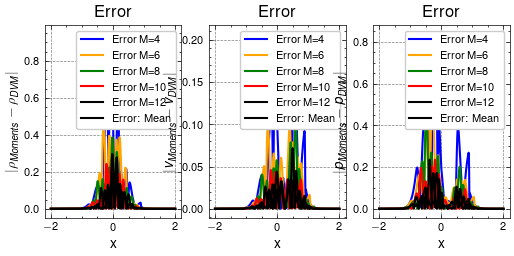

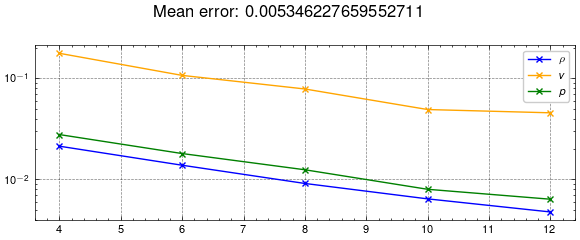

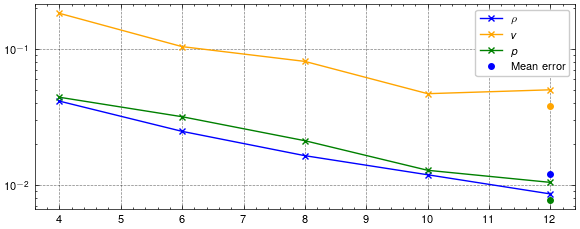

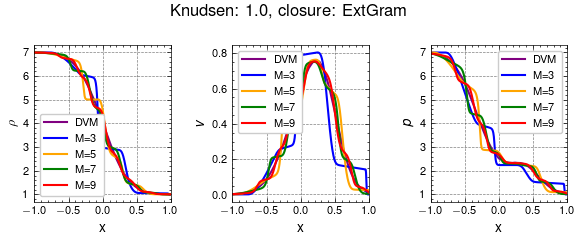

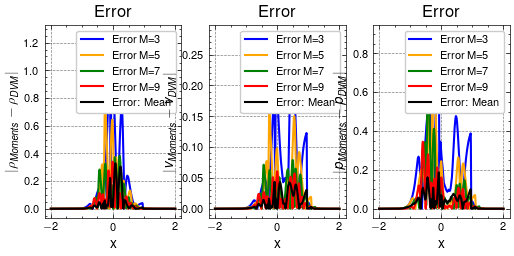

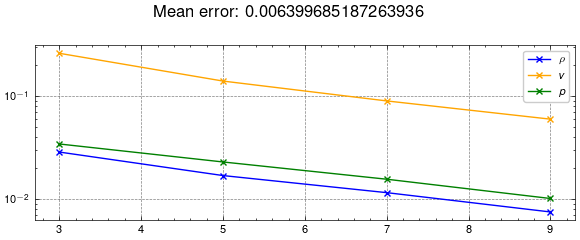

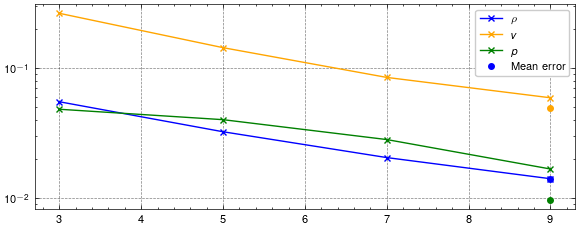

In [27]:
Moments_error_collected = [
    [4, 6, 8, 10, 12],
    [3, 5, 7, 9]
]

Kn = 1.0
closure = "ExtGram"

for Moments_error in Moments_error_collected:
    fig, axs = plt.subplots(1, 3)
    fig.suptitle(f'Knudsen: {Kn}, closure: {closure}')
    fig_error, axs_error = plt.subplots(1, 3)

    ax_rho = axs[0]
    ax_v = axs[1]
    ax_p = axs[2]

    [ax.set_xlim(-1, 1) for ax in [ax_rho, ax_v, ax_p]]
    [ax.set_xlabel('x') for ax in [ax_rho, ax_v, ax_p]]
    [ax.set_ylabel(label) for ax, label in zip([ax_rho, ax_v, ax_p], ['$\\rho$', '$v$', '$p$'])]

    # DVM
    data_DVM = pd.read_csv(f'../out/ShockTube/DVM/DVM_solution_N{N}_c_l{c_L}_c_u{c_R}_Kn{Kn}_source{source}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level_DVM}_polydeg{polydeg}_x_left{x_left_DVM}_x_right{x_right_DVM}_rho_v_p.csv')

    x_DVM = data_DVM['x'].to_numpy()

    rho_DVM = data_DVM['rho'].to_numpy()
    ax_rho.plot(x_DVM, rho_DVM, color=colors[5], lw=1.5, label='DVM')

    v_DVM = data_DVM['v'].to_numpy()
    ax_v.plot(x_DVM, v_DVM, color=colors[5], lw=1.5, label='DVM')

    p_DVM = data_DVM['p'].to_numpy()
    theta_DVM = p_DVM / rho_DVM
    ax_p.plot(x_DVM, p_DVM, color=colors[5], lw=1.5, label='DVM')

    rho_DVM_fct = lambda x_val: np.interp(x_val, x_DVM, rho_DVM)
    v_DVM_fct = lambda x_val: np.interp(x_val, x_DVM, v_DVM)
    p_DVM_fct = lambda x_val: np.interp(x_val, x_DVM, p_DVM)

    rho_vector, v_vector, p_vector = [], [], []
    rho_L1, v_L1, p_L1 = [], [], []
    rho_L2, v_L2, p_L2 = [], [], []

    for i, M in enumerate(Moments_error):
        # Moments
        file = f"../out/ShockTube/Moments/gram_solution_M{M}_closure{closure}_Kn{Kn}_source{source}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level}_polydeg{polydeg}_cons.tsv"

        x, u, _ = sol_final(file)
        rho = u[:, 0]
        rho_vector.append(rho)
        v = u[:, 1] / rho
        v_vector.append(v)
        p = (u[:, 2] - rho * v**2) # ?1/2 * u[:, 2]
        p_vector.append(p)
        theta = p / rho

        ax_rho.plot(x, rho, color=colors[i], lw=1.5, label=f'M={M}')
        ax_v.plot(x, v, color=colors[i], lw=1.5, label=f'M={M}')
        ax_p.plot(x, p, color=colors[i], lw=1.5, label=f'M={M}')

        axs_error[0].plot(x, np.abs(rho_DVM_fct(x) - rho), color=colors[i], lw=1.5, label=f'Error M={M}')
        axs_error[1].plot(x, np.abs(v_DVM_fct(x) - v), color=colors[i], lw=1.5, label=f'Error M={M}')
        axs_error[2].plot(x, np.abs(p_DVM_fct(x) - p), color=colors[i], lw=1.5, label=f'Error M={M}')

        rho_L1.append(np.linalg.norm(rho_DVM_fct(x) - rho, 1) / np.linalg.norm(rho_DVM_fct(x), 1))
        rho_L2.append(np.linalg.norm(rho_DVM_fct(x) - rho, 2) / np.linalg.norm(rho_DVM_fct(x), 2))
        v_L1.append(np.linalg.norm(v_DVM_fct(x) - v, 1) / np.linalg.norm(v_DVM_fct(x), 1))
        v_L2.append(np.linalg.norm(v_DVM_fct(x) - v, 2) / np.linalg.norm(v_DVM_fct(x), 2))
        p_L1.append(np.linalg.norm(p_DVM_fct(x) - p, 1) / np.linalg.norm(p_DVM_fct(x), 1))
        p_L2.append(np.linalg.norm(p_DVM_fct(x) - p, 2) / np.linalg.norm(p_DVM_fct(x), 2))

    rho_mean = np.mean(np.array(rho_vector), axis=0)
    v_mean = np.mean(np.array(v_vector), axis=0)
    p_mean = np.mean(np.array(p_vector), axis=0)

        # ax_rho.plot(x, rho_mean, color=colors[3], lw=1.5, label='Mean M=4,5')
        # ax_v.plot(x, v_mean, color=colors[3], lw=1.5, label='Mean M=4,5')
        # ax_p.plot(x, p_mean, color=colors[3], lw=1.5, label='Mean M=4,5')

    ax_rho.legend()
    ax_v.legend()
    ax_p.legend()

    axs_error[0].set_title('Error')
    axs_error[0].set_xlabel('x')
    axs_error[0].set_ylabel('$|\\rho_{Moments} - \\rho_{DVM}|$')
    axs_error[1].set_title('Error')
    axs_error[1].set_xlabel('x')
    axs_error[1].set_ylabel('$|v_{Moments} - v_{DVM}|$')
    axs_error[2].set_title('Error')
    axs_error[2].set_xlabel('x')
    axs_error[2].set_ylabel('$|p_{Moments} - p_{DVM}|$')

    axs_error[0].plot(x, np.abs(rho_DVM_fct(x) - rho_mean), color='black', lw=1.5, label="Error: Mean")
    axs_error[1].plot(x, np.abs(v_DVM_fct(x) - v_mean), color='black', lw=1.5, label="Error: Mean")
    axs_error[2].plot(x, np.abs(p_DVM_fct(x) - p_mean), color='black', lw=1.5, label="Error: Mean")

    [ax.legend() for ax in axs_error]

    fig.tight_layout()
    fig.show()

    fig_L1, axs_L1 = plt.subplots()
    fig_L1.suptitle(f'Mean error: {np.linalg.norm(rho_DVM_fct(x) - rho_mean, 1) / np.linalg.norm(rho_DVM_fct(x), 1)}')
    axs_L1.semilogy(Moments_error, rho_L1, '-x', color=colors[0], label="$\\rho$")
    axs_L1.semilogy(Moments_error, v_L1, '-x', color=colors[1], label='$v$')
    axs_L1.semilogy(Moments_error, p_L1, '-x', color=colors[2], label='$p$')
    axs_L1.legend()

    fig_L1.tight_layout()
    fig_L1.show()



    fig_L2, axs_L2 = plt.subplots()
    # fig_L2.suptitle(f'Mean error: {np.linalg.norm(rho_DVM_fct(x) - rho_mean, 2) / np.linalg.norm(rho_DVM_fct(x), 2)}')
    axs_L2.semilogy(Moments_error, rho_L2, '-x', color=colors[0], label="$\\rho$")
    axs_L2.semilogy(Moments_error, v_L2, '-x', color=colors[1], label='$v$')
    axs_L2.semilogy(Moments_error, p_L2, '-x', color=colors[2], label='$p$')
    axs_L2.scatter(Moments_error[-1], np.linalg.norm(rho_DVM_fct(x) - rho_mean, 2) / np.linalg.norm(rho_DVM_fct(x), 2), color=colors[0], label='Mean error')
    axs_L2.scatter(Moments_error[-1], np.linalg.norm(v_DVM_fct(x) - v_mean, 2) / np.linalg.norm(v_DVM_fct(x), 2), color=colors[1])
    axs_L2.scatter(Moments_error[-1], np.linalg.norm(p_DVM_fct(x) - p_mean, 2) / np.linalg.norm(p_DVM_fct(x), 2), color=colors[2])
    axs_L2.legend()

    fig_L2.tight_layout()
    fig_L2.show()

## Test-values for analytical

In [28]:
base_tree_level = 10
M = 4
closure = "Gram"

file = f"../out/ShockTube/Moments/gram_solution_M{M}_closure{closure}_Kn{Kn}_source{source}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level}_polydeg{polydeg}_cons.tsv"

x, u, _ = sol_final(file)

file = f"../out/ShockTube/Moments/gram_solution_M{M}_closure{closure}_Kn{Kn}_source{source}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level}_polydeg{polydeg}_eigenvalues.csv"
df = pd.read_csv(file)
# x_dest = 0.0
# x_idx = (np.abs(df['x_vector'] - x_dest)).argmin()
# eigenvalues_at_x = df['eigenvalue'][x_idx]
eigenvalue_string = df['eigenvalue'][0]
eigenvalues_at_x = [float(val) for val in eigenvalue_string.strip('[]').split(',')]
eigenvalues_at_x, len(eigenvalues_at_x), type(eigenvalues_at_x)

([-1.7320508075688705,
  -1.0000000000000164,
  7.343512411761791e-18,
  1.000000000000016,
  1.7320508075688683],
 5,
 list)

-------------------------
Closure: Gram
Closure: Gram
Moments:  [7.000000000000001, -4.9404924595819466e-15, 7.000000000000006, -5.47417018081704e-16]
Eigenvalues:  [-1.0, -1.0, 0.9999999834749049, 1.0000000165250944]


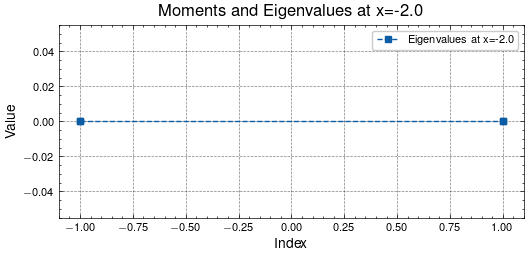

-------------------------
Closure: Gram
Moments:  [4.0014973773228775, 2.893974620473147, 3.986118214223126, 3.3005539652041005]
Eigenvalues:  [-0.8109583442560953, -0.8109583174165251, 1.0315992919326935, 1.0315993020622427]


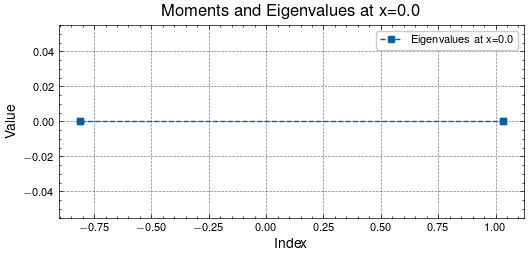

-------------------------
-------------------------
Closure: ExtGram
Closure: ExtGram
Moments:  [7.000000000000001, -4.9404924595819466e-15, 7.000000000000006, -1.2217194095693162e-15]
Eigenvalues:  [-2.33441421833898, -0.7419637843027249, 0.7419637843027269, 2.3344142183389787]


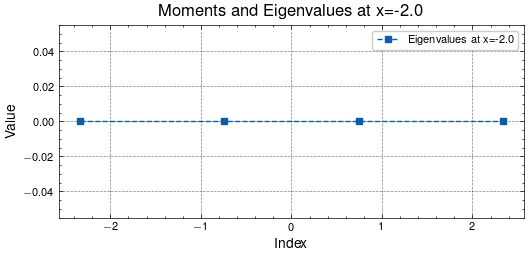

-------------------------
Closure: ExtGram
Moments:  [2.9732146762373466, 2.344749821747976, 4.09267488004232, 4.795672997850749]
Eigenvalues:  [-3.1125461137562493, -0.38885870379580456, 1.080664165326824, 2.0619745776126446]


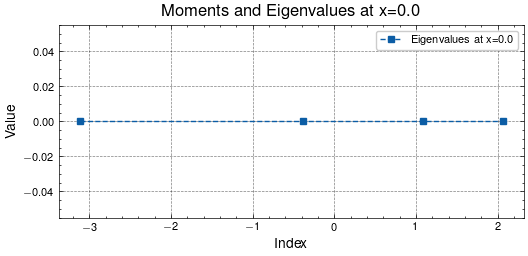

-------------------------
-------------------------
Closure: Grad
Closure: Grad
Moments:  [7.000000000000001, -4.9404924595819466e-15, 7.000000000000006, -1.2826827767740692e-15]
Eigenvalues:  [-2.3344142183389787, -0.7419637843027277, 0.7419637843027238, 2.3344142183389796]


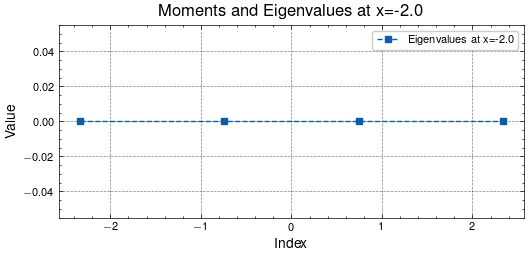

-------------------------
Closure: Grad
Moments:  [3.830646372252716, 2.1676179011042764, 4.063139955181084, 4.9899117066374306]
Eigenvalues:  [-1.5134047206988779, -0.003693845755694343, 1.2861047452526764, 2.4944425350329666]


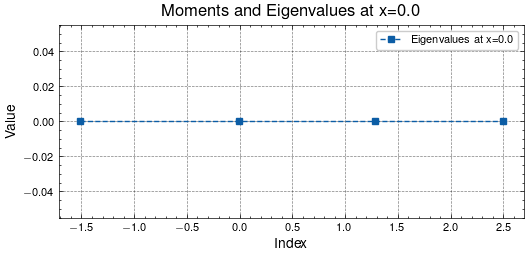

-------------------------
-------------------------
Closure: Gram
Closure: Gram
Moments:  [7.000000000000003, -4.163336342344337e-17, 7.000000000000014, -2.7911386133208365e-16, 21.00000000000005]
Eigenvalues:  [-1.7320508075688705, -1.0000000000000164, 7.343512411761791e-18, 1.000000000000016, 1.7320508075688683]


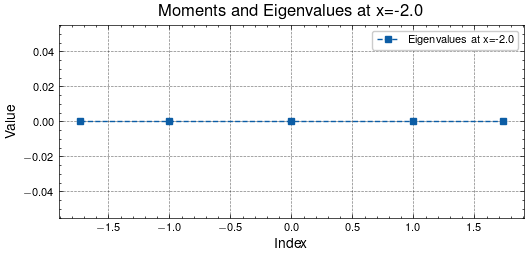

-------------------------
Closure: Gram
Moments:  [4.0650907550333475, 2.0383488637067035, 3.9588654955706986, 5.024542500022368, 11.605619181454587]
Eigenvalues:  [-1.8078602772817343, -0.33263458572158683, 0.10227345381302826, 1.3675954533696728, 1.705588341835701]


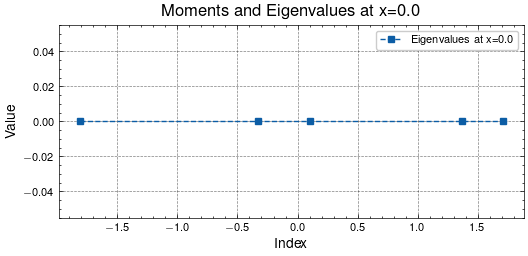

-------------------------
-------------------------
Closure: ExtGram
Closure: ExtGram
Moments:  [7.000000000000003, -4.163336342344337e-17, 7.000000000000014, -2.7911386133208246e-16, 21.00000000000005]
Eigenvalues:  [-2.449489742783165, -1.000000000000013, -7.783500853665858e-18, 1.0000000000000138, 2.449489742783166]


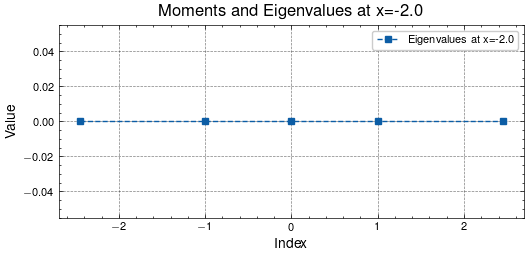

-------------------------
Closure: ExtGram
Moments:  [3.550026843708628, 2.491368531953177, 4.076295856289046, 4.763311397172827, 11.550461451246191]
Eigenvalues:  [-2.2518592611616595, -0.4525403891587826, 0.6708755295229323, 1.269855313553854, 2.8069569592530366]


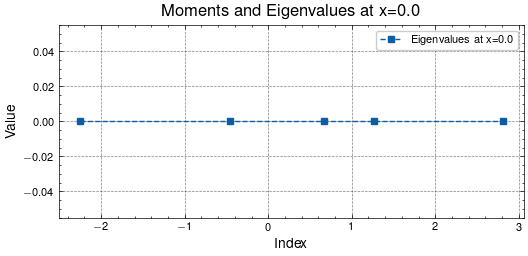

-------------------------
-------------------------
Closure: Grad
Closure: Grad
Moments:  [7.000000000000003, -4.163336342344337e-17, 7.000000000000014, -2.7911386133208286e-16, 21.00000000000005]
Eigenvalues:  [-2.8569700138728154, -1.3556261799742741, 2.675136810217403e-16, 1.3556261799742746, 2.8569700138728176]


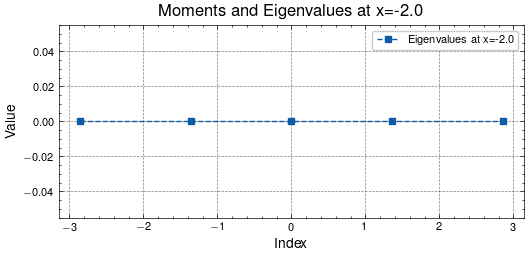

-------------------------
Closure: Grad
Moments:  [3.7237838663533758, 2.4343211232987274, 4.037715071112302, 4.682822651854784, 11.658997546544741]
Eigenvalues:  [-2.0411421127106273, -0.0684496968028034, 1.2651713394740058, 1.2651713394740058, 2.8478613952222687]


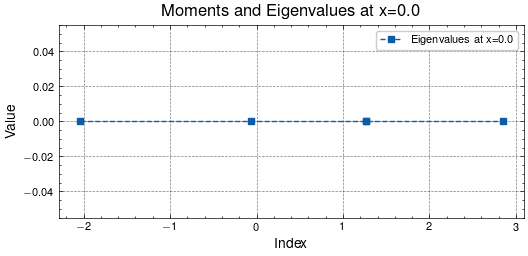

-------------------------


In [29]:
M_vector = [3, 4]
for M in M_vector:
    for closure in closure_vec:
        print("-------------------------")
        print(f'Closure: {closure}')
        file = f"../out/ShockTube/Moments/gram_solution_M{M}_closure{closure}_Kn{Kn}_source{source}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level}_polydeg{polydeg}_cons.tsv"

        x, u, _ = sol_final(file)

        file = f"../out/ShockTube/Moments/gram_solution_M{M}_closure{closure}_Kn{Kn}_source{source}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level}_polydeg{polydeg}_eigenvalues.csv"
        df = pd.read_csv(file)


        x_dest = -2.0
        x_idx = (np.abs(df['x_vector'] - x_dest)).argmin()
        eigenvalue_string = df['eigenvalue'][x_idx]
        eigenvalues_at_x = [float(val) for val in eigenvalue_string.strip('[]').split(',')]

        print(f"Closure: {closure}")
        print(f"Moments: ", df['moments'][x_idx])
        print("Eigenvalues: ", eigenvalues_at_x)

        plt.subplots()
        plt.plot(eigenvalues_at_x, [0]*len(eigenvalues_at_x), 's--', label=f'Eigenvalues at x={x_dest}')
        plt.xlabel('Index')
        plt.ylabel('Value')
        plt.title(f'Moments and Eigenvalues at x={x_dest}')
        plt.legend()
        plt.show()

        print("-------------------------")

        x_dest = 0.0
        x_idx = (np.abs(df['x_vector'] - x_dest)).argmin()
        eigenvalue_string = df['eigenvalue'][x_idx]
        eigenvalues_at_x = [float(val) for val in eigenvalue_string.strip('[]').split(',')]

        print(f"Closure: {closure}")
        print(f"Moments: ", df['moments'][x_idx])
        print("Eigenvalues: ", eigenvalues_at_x)

        plt.subplots()
        plt.plot(eigenvalues_at_x, [0]*len(eigenvalues_at_x), 's--', label=f'Eigenvalues at x={x_dest}')
        plt.xlabel('Index')
        plt.ylabel('Value')
        plt.title(f'Moments and Eigenvalues at x={x_dest}')
        plt.legend()
        plt.show()

        print("-------------------------")

# Analytical

### M = 4

In [30]:
from sympy import *
u0, u1, u2, u3, u4, u5 = symbols('u0 u1 u2 u3 u4 u5')
c = symbols('c')
init_printing(use_unicode=True)

In [31]:
M = 4
n = int(M/2)

## Gramian

In [32]:
P_Gramian = lambda c: (
    c**2 - Matrix(Matrix([1, c]).T * Matrix([[u0, u1], [u1, u2]]).inv() * Matrix([u2, u3]))[0]     # p_n(c)
) * (
    c**3 - Matrix(Matrix([1, c]).T * Matrix([[u0, u1], [u1, u2]]).inv() * Matrix([u3, u4]))[0]  # p_np(c) -> equation 42
)
P = simplify(P_Gramian(c))

print(f'Latex expression of characteristic polynomial: {latex(P_Gramian)}')
P_Gramian

Latex expression of characteristic polynomial: \mathtt{\text{<function <lambda> at 0x153ac25c0>}}


<function __main__.<lambda>(c)>

In [33]:
#! We don't want to use this, it seems to add imaginary parts due to numerical errors

# # Roots of P give the eigenvalues of DF
# roots = solve(Eq(P, 0), c)
# roots = [simplify(root) for root in roots]
# print(f'Latex expression of roots: {latex(roots)}')
# roots

In [34]:
# Get numerical eigenvalues at x=-2.0 (equilibrium)

closure = "Gram"
source = "relaxation_source"
file = f"../out/ShockTube/Moments/gram_solution_M{M}_closure{closure}_Kn{Kn}_source{source}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level}_polydeg{polydeg}_cons.tsv"

x, u, _ = sol_final(file)

file = f"../out/ShockTube/Moments/gram_solution_M{M}_closure{closure}_Kn{Kn}_source{source}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level}_polydeg{polydeg}_eigenvalues.csv"
df = pd.read_csv(file)


x_dest = -2.0
x_idx = (np.abs(df['x_vector'] - x_dest)).argmin()
eigenvalue_string = df['eigenvalue'][x_idx]
eigenvalues_test_equilibrium = [float(val) for val in eigenvalue_string.strip('[]').split(',')]

In [35]:
moments_test_equilibrium = [
    7.0, 
    0.0, 
    7.0, 
    0.0, 
    21.0
]

subs_dict_equilibrium = {
    u0: moments_test_equilibrium[0],
    u1: moments_test_equilibrium[1],
    u2: moments_test_equilibrium[2],
    u3: moments_test_equilibrium[3],
    u4: moments_test_equilibrium[4]
}

P_Gramian_subs = P_Gramian(c).subs(subs_dict_equilibrium)
P_Gramian_subs = simplify(P_Gramian_subs)

roots = solve(Eq(P_Gramian_subs, 0), c)
roots_subs = [simplify(root) for root in roots]

# Sort eigenvalues for easier comparison
# First assert that maximum imaginary eigenvalue part is small
max_imag_rouots = max([abs(re(root.subs(subs_dict_equilibrium).evalf().as_real_imag()[1])) for root in roots])
assert max_imag_rouots < 1e-10, f"Maximum imaginary part of eigenvalues is too large: {max_imag_rouots}"
roots_subs = [root.subs(subs_dict_equilibrium).evalf().as_real_imag()[0] for root in roots]
roots_subs.sort()
eigenvalues_test_equilibrium.sort()

print("Sorted Computed Eigenvalues:", roots_subs)
print("Sorted Test Eigenvalues:", eigenvalues_test_equilibrium)
# Check if computed eigenvalues match test eigenvalues
err_rel, err_abs = [], []
for r_computed, r_test in zip(roots_subs, eigenvalues_test_equilibrium):
    err_rel.append(abs(r_computed - r_test) / abs(r_test))
    err_abs.append(abs(r_computed - r_test))
print("Relative Errors:", err_rel)
print("Absolute Errors:", err_abs)

Sorted Computed Eigenvalues: [-1.73205080756888, -1.00000000000000, 0, 1.00000000000000, 1.73205080756888]
Sorted Test Eigenvalues: [-1.7320508075688705, -1.0000000000000164, 7.343512411761791e-18, 1.000000000000016, 1.7320508075688683]
Relative Errors: [3.84592537276714e-15, 1.64313007644520e-14, 1.00000000000000, 1.59872115546020e-14, 5.12790049702286e-15]
Absolute Errors: [6.66133814775094e-15, 1.64313007644523e-14, 7.34351241176179e-18, 1.59872115546023e-14, 8.88178419700125e-15]


In [36]:
# Get numerical eigenvalues at x=0.0 (equilibrium)
x_dest = 0.0
x_idx = (np.abs(df['x_vector'] - x_dest)).argmin()
eigenvalue_string = df['eigenvalue'][x_idx]
eigenvalues_test = [float(val) for val in eigenvalue_string.strip('[]').split(',')]
moments_string = df['moments'][x_idx]
moments_test = [float(val) for val in moments_string.strip('[]').split(',')]

In [37]:
subs_dict = {
    u0: moments_test[0],
    u1: moments_test[1],
    u2: moments_test[2],
    u3: moments_test[3],
    u4: moments_test[4]
}

P_Gramian_subs = P_Gramian(c).subs(subs_dict)
P_Gramian_subs = simplify(P_Gramian_subs)

roots = solve(Eq(P_Gramian_subs, 0), c)
roots_subs = [simplify(root) for root in roots]

# Sort eigenvalues for easier comparison
# First assert that maximum imaginary eigenvalue part is small
max_imag_rouots = max([abs(re(root.subs(subs_dict).evalf().as_real_imag()[1])) for root in roots])
assert max_imag_rouots < 1e-10, f"Maximum imaginary part of eigenvalues is too large: {max_imag_rouots}"
roots_subs = [root.subs(subs_dict).evalf().as_real_imag()[0] for root in roots]
roots_subs.sort()
eigenvalues_test.sort()

print("Sorted Computed Eigenvalues:", roots_subs)
print("Sorted Test Eigenvalues:", eigenvalues_test)
# Check if computed eigenvalues match test eigenvalues
err_rel, err_abs = [], []
for r_computed, r_test in zip(roots_subs, eigenvalues_test):
    err_rel.append(abs(r_computed - r_test) / abs(r_test))
    err_abs.append(abs(r_computed - r_test))
print("Relative Errors:", err_rel)
print("Absolute Errors:", err_abs)

Sorted Computed Eigenvalues: [-1.80786042693896, -0.332634648413377, 0.102273422508968, 1.36759703781471, 1.70558700442999]
Sorted Test Eigenvalues: [-1.8078602772817343, -0.33263458572158683, 0.10227345381302826, 1.3675954533696728, 1.705588341835701]
Relative Errors: [8.27814092631686e-8, 1.88470450442112e-7, 3.06081968208717e-7, 1.15856266586887e-6, 7.84131598746162e-7]
Absolute Errors: [1.49657221504285e-7, 6.26917902035729e-8, 3.13040600385950e-8, 1.58444503428612e-6, 1.33740571328644e-6]


## Extended Gramian

In [38]:
chi = (n+1) / n

In [39]:
p_nm = lambda c: c**1 - Matrix(Matrix([1]).T * Matrix([u0]).inv() * Matrix([u1]))[0]
p_n = lambda c: c**2 - Matrix(Matrix([1, c]).T * Matrix([[u0, u1], [u1, u2]]).inv() * Matrix([u2, u3]))[0]
p_np = lambda c: c**3 - Matrix(Matrix([1, c]).T * Matrix([[u0, u1], [u1, u2]]).inv() * Matrix([u3, u4]))[0]  # p_np(c) -> equation 42

sigma_nn = Matrix([u4])[0] - Matrix(Matrix([u2, u3]).T * Matrix([[u0, u1],[u1, u2]]).inv() * Matrix([u2, u3]))[0]
sigma_nmnm = u2 - u1 * u1 / u0

In [40]:
P_ExtendedGramian = lambda c: p_n(c) * (p_np(c) - chi * sigma_nn / sigma_nmnm * p_nm(c)) 
P = simplify(P_ExtendedGramian(c))

print(f'Latex expression of characteristic polynomial: {latex(P)}')
P_ExtendedGramian

Latex expression of characteristic polynomial: \frac{\left(c^{2} \left(- u_{0} u_{2} + u_{1}^{2}\right) - u_{2} \left(c u_{1} - u_{2}\right) + u_{3} \left(c u_{0} - u_{1}\right)\right) \left(- c^{3} \left(u_{0} u_{2} - u_{1}^{2}\right)^{2} - 1.5 \left(c u_{0} - u_{1}\right) \left(u_{2} \left(- u_{1} u_{3} + u_{2}^{2}\right) + u_{3} \left(u_{0} u_{3} - u_{1} u_{2}\right) - u_{4} \left(u_{0} u_{2} - u_{1}^{2}\right)\right) + \left(u_{0} u_{2} - u_{1}^{2}\right) \left(- u_{3} \left(c u_{1} - u_{2}\right) + u_{4} \left(c u_{0} - u_{1}\right)\right)\right)}{\left(u_{0} u_{2} - u_{1}^{2}\right)^{3}}


<function __main__.<lambda>(c)>

In [41]:
# Get numerical eigenvalues at x=-2.0 (equilibrium)
closure = "ExtGram"
file = f"../out/ShockTube/Moments/gram_solution_M{M}_closure{closure}_Kn{Kn}_source{source}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level}_polydeg{polydeg}_cons.tsv"

x, u, _ = sol_final(file)

file = f"../out/ShockTube/Moments/gram_solution_M{M}_closure{closure}_Kn{Kn}_source{source}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level}_polydeg{polydeg}_eigenvalues.csv"
df = pd.read_csv(file)


x_dest = -2.0
x_idx = (np.abs(df['x_vector'] - x_dest)).argmin()
eigenvalue_string = df['eigenvalue'][x_idx]
eigenvalues_test_equilibrium = [float(val) for val in eigenvalue_string.strip('[]').split(',')]

In [42]:
moments_test_equilibrium = [
    7.0, 
    0.0, 
    7.0, 
    0.0, 
    21.0
]

subs_dict_equilibrium = {
    u0: moments_test_equilibrium[0],
    u1: moments_test_equilibrium[1],
    u2: moments_test_equilibrium[2],
    u3: moments_test_equilibrium[3],
    u4: moments_test_equilibrium[4]
}

P_ExtendedGramian_subs = P_ExtendedGramian(c).subs(subs_dict_equilibrium)
P_ExtendedGramian_subs = simplify(P_ExtendedGramian_subs)

roots = solve(Eq(P_ExtendedGramian_subs, 0), c)
roots_subs = [simplify(root) for root in roots]
# roots_subs = [root.subs(subs_dict_equilibrium).evalf() for root in roots]

print("Computed Eigenvalues at Equilibrium:", roots_subs)
# Sort eigenvalues for easier comparison
# First assert that maximum imaginary eigenvalue part is small
max_imag_rouots = max([abs(re(root.subs(subs_dict_equilibrium).evalf().as_real_imag()[1])) for root in roots])
assert max_imag_rouots < 1e-10, f"Maximum imaginary part of eigenvalues is too large: {max_imag_rouots}"
roots_subs = [root.subs(subs_dict_equilibrium).evalf().as_real_imag()[0] for root in roots]
roots_subs.sort()
eigenvalues_test_equilibrium.sort()

print("Sorted Computed Eigenvalues:", roots_subs)
print("Sorted Test Eigenvalues:", eigenvalues_test_equilibrium)
# Check if computed eigenvalues match test eigenvalues
err_rel, err_abs = [], []
for r_computed, r_test in zip(roots_subs, eigenvalues_test_equilibrium):
    err_rel.append(abs(r_computed - r_test) / abs(r_test))
    err_abs.append(abs(r_computed - r_test))
print("Relative Errors:", err_rel)
print("Absolute Errors:", err_abs)

Computed Eigenvalues at Equilibrium: [-2.44948974278318, -1.00000000000000, 0.0, 1.00000000000000, 2.44948974278318]
Sorted Computed Eigenvalues: [-2.44948974278318, -1.00000000000000, 0, 1.00000000000000, 2.44948974278318]
Sorted Test Eigenvalues: [-2.449489742783165, -1.000000000000013, -7.783500853665858e-18, 1.0000000000000138, 2.449489742783166]
Relative Errors: [5.25766116130737e-15, 1.31006316905767e-14, 1.00000000000000, 1.37667655053518e-14, 4.89506383983789e-15]
Absolute Errors: [1.28785870856518e-14, 1.31006316905768e-14, 7.78350085366586e-18, 1.37667655053519e-14, 1.19904086659517e-14]


In [43]:
# Get numerical eigenvalues at x=0.0 (equilibrium)
x_dest = 0.0
x_idx = (np.abs(df['x_vector'] - x_dest)).argmin()
eigenvalue_string = df['eigenvalue'][x_idx]
eigenvalues_test = [float(val) for val in eigenvalue_string.strip('[]').split(',')]
moments_string = df['moments'][x_idx]
moments_test = [float(val) for val in moments_string.strip('[]').split(',')]

In [44]:
subs_dict = {
    u0: moments_test[0],
    u1: moments_test[1],
    u2: moments_test[2],
    u3: moments_test[3],
    u4: moments_test[4]
}

P_ExtendedGramian_subs = P_ExtendedGramian(c).subs(subs_dict)
P_ExtendedGramian_subs = simplify(P_ExtendedGramian_subs)
print(P_ExtendedGramian_subs)

roots = solve(Eq(P_ExtendedGramian_subs, 0), c)
roots_subs = [simplify(root) for root in roots]
print(roots_subs)
# roots_subs = [root.subs(subs_dict).evalf() for root in roots]

# Sort eigenvalues for easier comparison
# First assert that maximum imaginary eigenvalue part is small
max_imag_rouots = max([abs(re(root.subs(subs_dict).evalf().as_real_imag()[1])) for root in roots])
assert max_imag_rouots < 1e-10, f"Maximum imaginary part of eigenvalues is too large: {max_imag_rouots}"
roots_subs = [root.subs(subs_dict).evalf().as_real_imag()[0] for root in roots]
roots_subs.sort()
eigenvalues_test.sort()

print("Sorted Computed Eigenvalues:", roots_subs)
print("Sorted Test Eigenvalues:", eigenvalues_test)
# Check if computed eigenvalues match test eigenvalues
err_rel, err_abs = [], []
for r_computed, r_test in zip(roots_subs, eigenvalues_test):
    err_rel.append(abs(r_computed - r_test) / abs(r_test))
    err_abs.append(abs(r_computed - r_test))
print("Relative Errors:", err_rel)
print("Absolute Errors:", err_abs)

-(-c**2 + 0.817315261890856*c + 0.574661100308158)*(c**3 - 6.9504786578284*c + 3.53599929397697)
[-0.452540464522791, 1.26985572641365, -2.86117693829085 - 0.e-22*I, 0.530183808077506 + 0.e-20*I, 2.33099313021335 + 0.e-20*I]
Sorted Computed Eigenvalues: [-2.86117693829085, -0.452540464522791, 0.530183808077506, 1.26985572641365, 2.33099313021335]
Sorted Test Eigenvalues: [-2.2518592611616595, -0.4525403891587826, 0.6708755295229323, 1.269855313553854, 2.8069569592530366]
Relative Errors: [0.270584262364099, 1.66535430269279e-7, 0.209713598505335, 3.25123491324620e-7, 0.169565773878610]
Absolute Errors: [0.609317677129193, 7.53640084227847e-8, 0.140691721445426, 4.12859793019749e-7, 0.475963829039690]


## Visualize eigenvalues in equilibrium

In [45]:
moments_test_equilibrium = [
    7.0, 
    0.0, 
    7.0, 
    0.0, 
    21.0
]

subs_dict_equilibrium = {
    u0: moments_test_equilibrium[0],
    u1: moments_test_equilibrium[1],
    u2: moments_test_equilibrium[2],
    u3: moments_test_equilibrium[3],
    u4: moments_test_equilibrium[4]
}

# Gramian
P_Gramian_subs = P_Gramian(c).subs(subs_dict_equilibrium)
P_Gramian_subs = simplify(P_Gramian_subs)

roots_Gramian = solve(Eq(P_Gramian_subs, 0), c)
roots_subs_Gramian = [simplify(root) for root in roots_Gramian]

# Extended Gramian
P_ExtendedGramian_subs = P_ExtendedGramian(c).subs(subs_dict_equilibrium)
P_ExtendedGramian_subs = simplify(P_ExtendedGramian_subs)

roots_ExtendedGramian = solve(Eq(P_ExtendedGramian_subs, 0), c)
roots_subs_ExtendedGramian = [simplify(root) for root in roots_ExtendedGramian]

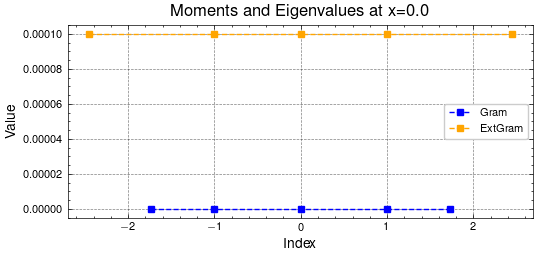

In [46]:
plt.subplots()
plt.plot(roots_subs_Gramian, [0]*len(roots_subs_Gramian), 's--', color='blue', label=f'Gram')
plt.plot(roots_subs_ExtendedGramian, [1e-4]*len(roots_subs_ExtendedGramian), 's--', color='orange', label=f'ExtGram')
plt.xlabel('Index')
plt.ylabel('Value')
plt.title(f'Moments and Eigenvalues at x={x_dest}')
plt.legend()
plt.show()